In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/poster-dli/Myocardial_infarction.csv


In [ ]:
data = pd.read_csv('/kaggle/input/poster-dli/Myocardial_infarction.csv')

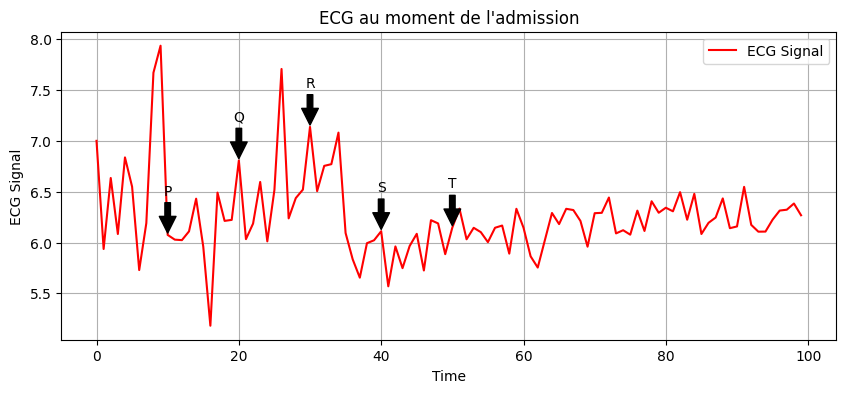

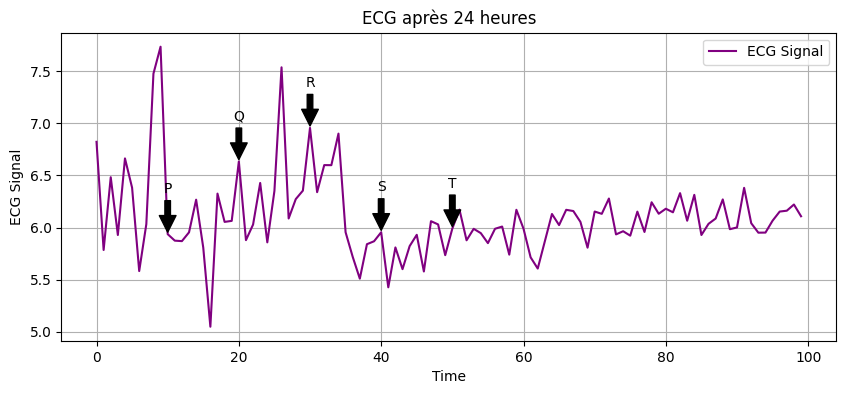

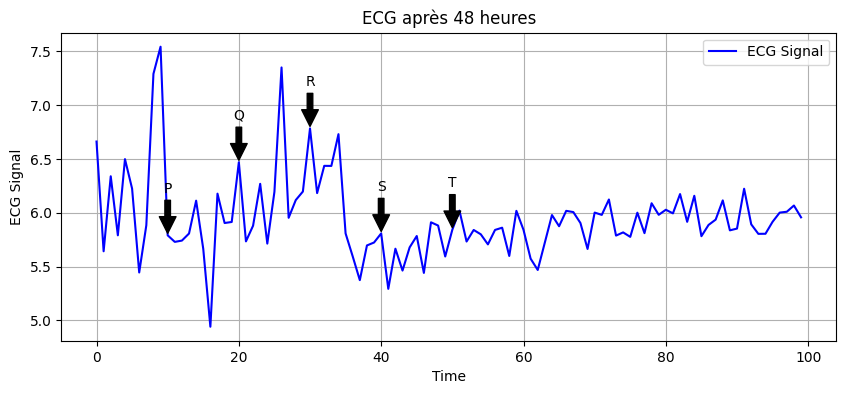

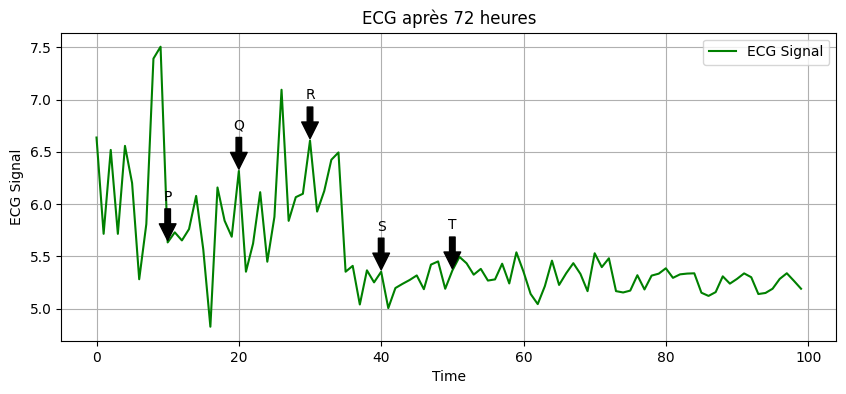

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# Définir les colonnes pour chaque scénario
columns_admission = [col for col in data.columns if col not in data.columns[[93, 94, 95, 100, 101, 102, 103, 104, 105]]]
columns_24h = [col for col in data.columns if col not in data.columns[[94, 95, 101, 102, 104, 105]]]
columns_48h = [col for col in data.columns if col not in data.columns[[95, 102, 105]]]
columns_72h = data.columns[2:112]

# Filtrer uniquement les colonnes numériques
def select_numeric_columns(data, columns):
    return data[columns].select_dtypes(include=['number'])

data_admission = select_numeric_columns(data, columns_admission)
data_24h = select_numeric_columns(data, columns_24h)
data_48h = select_numeric_columns(data, columns_48h)
data_72h = select_numeric_columns(data, columns_72h)

# Simuler les tracés ECG avec annotations pour les ondes P, Q, R, S, T
def simulate_ecg_with_waves(data, title, color):
    time = range(0, 100)
    ecg_signal = data.mean(axis=1).values[:100]  # Just a placeholder for a real ECG signal
    plt.figure(figsize=(10, 4))
    plt.plot(time, ecg_signal, label='ECG Signal', color=color)

    # Annotating P, Q, R, S, T waves
    wave_points = {'P': 10, 'Q': 20, 'R': 30, 'S': 40, 'T': 50}
    for wave, t in wave_points.items():
        plt.annotate(wave, xy=(t, ecg_signal[t]), xytext=(t, ecg_signal[t] + 0.5),
                     arrowprops=dict(facecolor='black', shrink=0.05),
                     horizontalalignment='center', verticalalignment='top')

    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('ECG Signal')
    plt.legend()
    plt.grid(True)
    plt.show()

# Tracer les scénarios avec des couleurs différentes
simulate_ecg_with_waves(data_admission, "ECG au moment de l'admission", color='red')
simulate_ecg_with_waves(data_24h, "ECG après 24 heures", color='purple')
simulate_ecg_with_waves(data_48h, "ECG après 48 heures", color='blue')
simulate_ecg_with_waves(data_72h, "ECG après 72 heures", color='green')


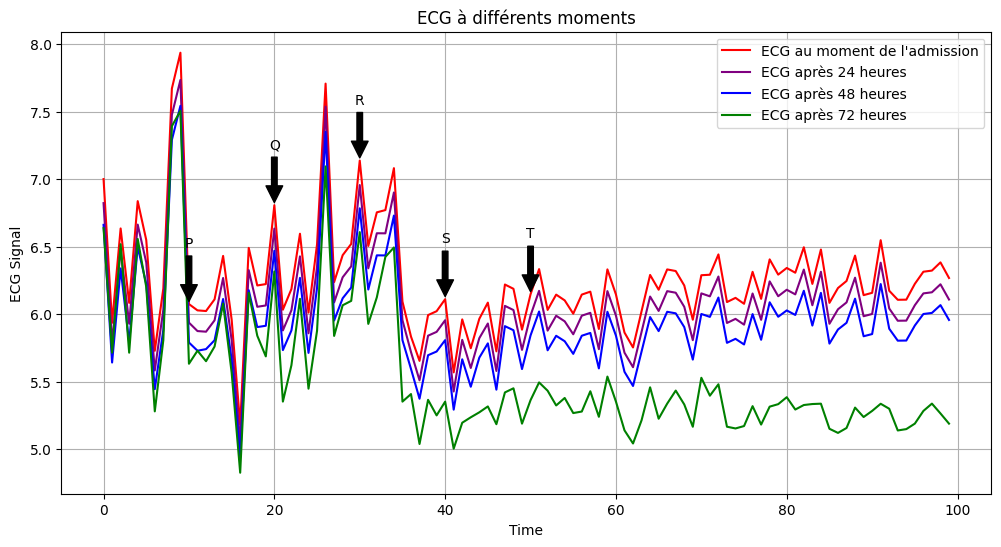

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données


# Définir les colonnes pour chaque scénario
columns_admission = [col for col in data.columns if col not in data.columns[[93, 94, 95, 100, 101, 102, 103, 104, 105]]]
columns_24h = [col for col in data.columns if col not in data.columns[[94, 95, 101, 102, 104, 105]]]
columns_48h = [col for col in data.columns if col not in data.columns[[95, 102, 105]]]
columns_72h = data.columns[2:112]

# Filtrer uniquement les colonnes numériques
def select_numeric_columns(data, columns):
    return data[columns].select_dtypes(include=['number'])

data_admission = select_numeric_columns(data, columns_admission)
data_24h = select_numeric_columns(data, columns_24h)
data_48h = select_numeric_columns(data, columns_48h)
data_72h = select_numeric_columns(data, columns_72h)

# Simuler les tracés ECG avec annotations pour les ondes P, Q, R, S, T
def simulate_ecg_with_waves(data, label, color, annotate=False):
    time = range(0, 100)
    ecg_signal = data.mean(axis=1).values[:100]  # Just a placeholder for a real ECG signal
    plt.plot(time, ecg_signal, label=label, color=color)

    # Annotating P, Q, R, S, T waves (optional, can be added to one of the plots if needed)
    if annotate:
        wave_points = {'P': 10, 'Q': 20, 'R': 30, 'S': 40, 'T': 50}
        for wave, t in wave_points.items():
            plt.annotate(wave, xy=(t, ecg_signal[t]), xytext=(t, ecg_signal[t] + 0.5),
                         arrowprops=dict(facecolor='black', shrink=0.05),
                         horizontalalignment='center', verticalalignment='top')

# Créer une figure pour tracer tous les scénarios
plt.figure(figsize=(12, 6))

# Tracer les scénarios avec des couleurs différentes
simulate_ecg_with_waves(data_admission, "ECG au moment de l'admission", color='red', annotate=True)
simulate_ecg_with_waves(data_24h, "ECG après 24 heures", color='purple')
simulate_ecg_with_waves(data_48h, "ECG après 48 heures", color='blue')
simulate_ecg_with_waves(data_72h, "ECG après 72 heures", color='green')

# Ajouter des titres et légendes
plt.title('ECG à différents moments')
plt.xlabel('Time')
plt.ylabel('ECG Signal')
plt.legend()
plt.grid(True)

# Afficher le graphique
plt.show()


In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

# Charger les données
# file_path = '/mnt/data/Myocardial_infarction.csv'
# data = pd.read_csv(file_path)

# Traiter les valeurs manquantes et normaliser les données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters et définir n_init explicitement
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Calculer les moyennes des caractéristiques pour chaque cluster
cluster_means = data_with_clusters.groupby('Cluster').mean()

# Identifier les caractéristiques principales pour chaque cluster
top_features_per_cluster = {}
for cluster in range(4):
    cluster_data = cluster_means.loc[cluster]
    top_features = cluster_data.abs().nlargest(10).index.tolist()
    top_features_per_cluster[f'Cluster {cluster}'] = top_features

# Convertir le dictionnaire en DataFrame pour affichage
top_features_df = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in top_features_per_cluster.items()]))

# Définir les noms des clusters
cluster_names = {
    0: 'ECG et pression artérielle',
    1: 'Enzymes sanguines et traitements',
    2: 'Enzymes sanguines et angine de poitrine',
    3: 'Âgé et fonctions cardiaques'
}



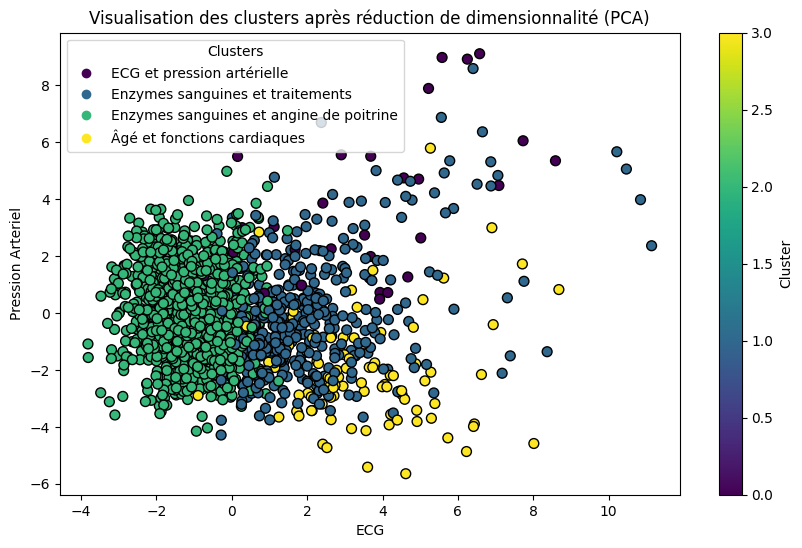

       Cluster 0      Cluster 1      Cluster 2      Cluster 3
0  ritm_ecg_p_04      KFK_BLOOD      KFK_BLOOD  ritm_ecg_p_02
1   n_p_ecg_p_06       R_AB_2_n  ritm_ecg_p_01     MP_TP_POST
2      D_AD_ORIT       R_AB_3_n  ritm_ecg_p_02   n_r_ecg_p_05
3      K_SH_POST       NA_R_2_n     MP_TP_POST   n_r_ecg_p_06
4  ritm_ecg_p_01  ritm_ecg_p_07       R_AB_2_n          nr_04
5  ritm_ecg_p_06         NITR_S         NITR_S  ritm_ecg_p_01
6         inf_im       NA_R_3_n       NA_R_2_n          nr_03
7      S_AD_ORIT       R_AB_1_n      STENOK_AN          ZSN_A
8        IM_PG_P       NA_R_1_n      FK_STENOK            AGE
9      KFK_BLOOD      FK_STENOK       R_AB_1_n  ritm_ecg_p_07
              AGE       SEX  INF_ANAM  STENOK_AN  FK_STENOK  IBS_POST  \
Cluster                                                                 
0        0.172343  0.061561 -0.102827   0.003465  -0.022813 -0.322200   
1        0.304355 -0.315074  0.397268   0.495661   0.498712  0.297442   
2       -0.164172  0.13860

In [ ]:
# Mapper les noms des clusters
cluster_labels = [cluster_names[label] for label in clusters]

# Réduire la dimensionnalité à 2D avec PCA pour la visualisation
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_preprocessed)

# Visualiser les clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters, cmap='viridis', marker='o', edgecolor='k', s=50)
plt.title('Visualisation des clusters après réduction de dimensionnalité (PCA)')
plt.xlabel('ECG')
plt.ylabel('Pression Arteriel')

# Ajouter la légende
handles, _ = scatter.legend_elements()
labels = [cluster_names[i] for i in range(4)]
plt.legend(handles, labels, title="Clusters")
plt.colorbar(label='Cluster')
plt.show()

# Afficher les résultats
print(top_features_df)
print(cluster_means)


In [ ]:
# Sélectionner les colonnes des complications
complications_columns = data.columns[113:124]

# Taux De Complications Par Hypertension

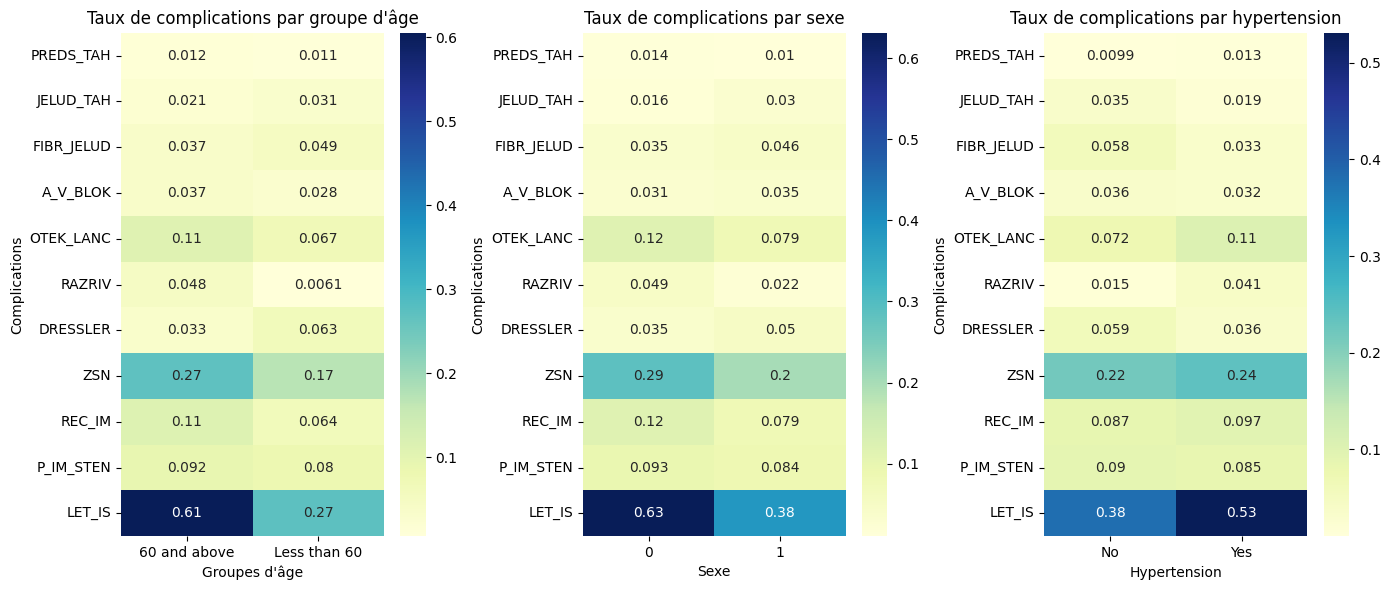

In [ ]:
# Définir les groupes basés sur l'âge, le sexe et la présence d'hypertension
data['Age_Group'] = data['AGE'].apply(lambda x: 'Less than 60' if x < 60 else '60 and above')
data['Hypertension'] = data['GB'].apply(lambda x: 'Yes' if x > 0 else 'No')

# Comparer les taux de complications entre les groupes d'âge
complications_by_age = data.groupby('Age_Group')[complications_columns].mean()

# Comparer les taux de complications entre les sexes
complications_by_sex = data.groupby('SEX')[complications_columns].mean()

# Comparer les taux de complications entre les groupes avec/sans hypertension
complications_by_hypertension = data.groupby('Hypertension')[complications_columns].mean()

# Visualiser les taux de complications par groupe d'âge
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.heatmap(complications_by_age.T, annot=True, cmap='YlGnBu', cbar=True)
plt.title('Taux de complications par groupe d\'âge')
plt.xlabel('Groupes d\'âge')
plt.ylabel('Complications')

# Visualiser les taux de complications par sexe
plt.subplot(1, 3, 2)
sns.heatmap(complications_by_sex.T, annot=True, cmap='YlGnBu', cbar=True)
plt.title('Taux de complications par sexe')
plt.xlabel('Sexe')
plt.ylabel('Complications')

# Visualiser les taux de complications par hypertension
plt.subplot(1, 3, 3)
sns.heatmap(complications_by_hypertension.T, annot=True, cmap='YlGnBu', cbar=True)
plt.title('Taux de complications par hypertension')
plt.xlabel('Hypertension')
plt.ylabel('Complications')

plt.tight_layout()
plt.show()


In [ ]:
# Sélectionner les colonnes pertinentes pour les traitements et les complications
treatment_columns = ['NA_KB', 'NOT_NA_KB', 'LID_KB', 'NITR_S', 'NA_R_1_n', 'NA_R_2_n', 'NA_R_3_n',
                     'NOT_NA_1_n', 'NOT_NA_2_n', 'NOT_NA_3_n', 'LID_S_n', 'B_BLOK_S_n', 'ANT_CA_S_n',
                     'GEPAR_S_n', 'ASP_S_n', 'TIKL_S_n', 'TRENT_S_n']

complications_columns = ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC',
                         'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN', 'LET_IS']

# Extraire les données des traitements et des complications
treatment_data = data[treatment_columns]
complications_data = data[complications_columns]

# Combiner les données de traitements et de complications
treatment_complication_data = pd.concat([treatment_data, complications_data], axis=1)

treatment_complication_data.head()


,NA_KB,NOT_NA_KB,LID_KB,NITR_S,NA_R_1_n,NA_R_2_n,NA_R_3_n,NOT_NA_1_n,NOT_NA_2_n,NOT_NA_3_n,...,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1.0,1.0,1.0,0.0,1.0,0.0,0.0,3.0,2.0,2.0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,1,0,0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


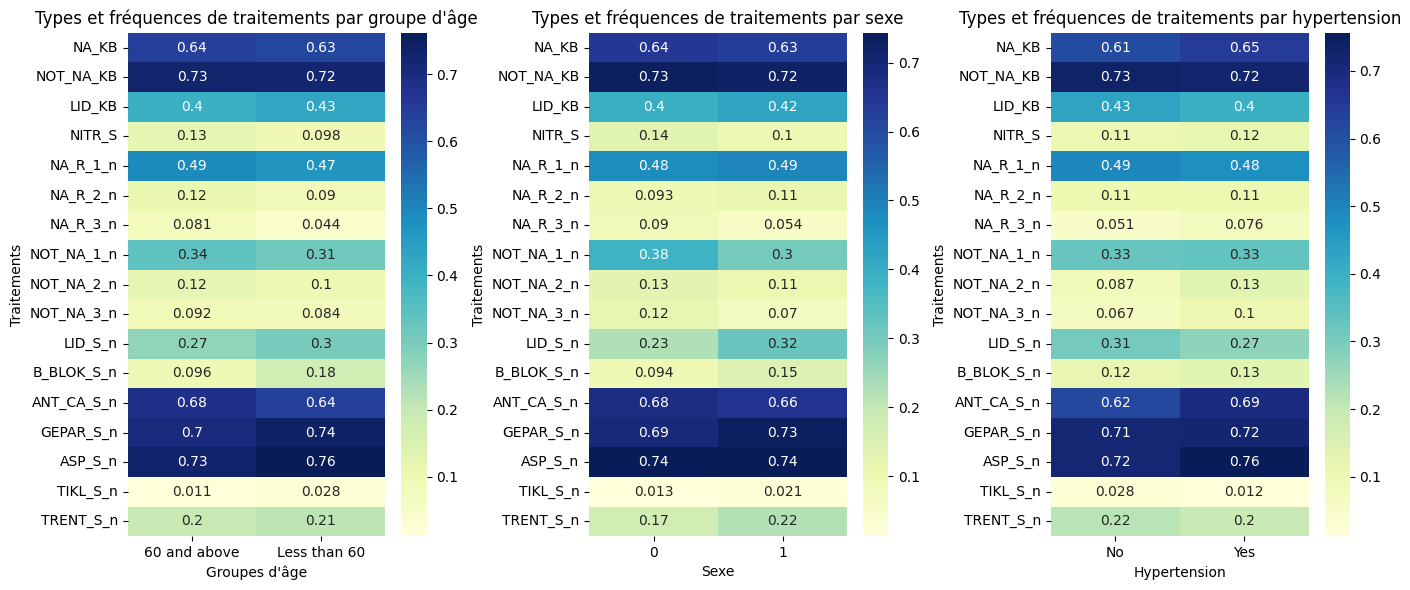

In [ ]:
# Comparer les types et fréquences de traitements entre les groupes d'âge
treatments_by_age = data.groupby('Age_Group')[treatment_columns].mean()

# Comparer les types et fréquences de traitements entre les sexes
treatments_by_sex = data.groupby('SEX')[treatment_columns].mean()

# Comparer les types et fréquences de traitements entre les groupes avec/sans hypertension
treatments_by_hypertension = data.groupby('Hypertension')[treatment_columns].mean()

# Visualiser les types et fréquences de traitements par groupe d'âge
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.heatmap(treatments_by_age.T, annot=True, cmap='YlGnBu', cbar=True)
plt.title('Types et fréquences de traitements par groupe d\'âge')
plt.xlabel('Groupes d\'âge')
plt.ylabel('Traitements')

# Visualiser les types et fréquences de traitements par sexe
plt.subplot(1, 3, 2)
sns.heatmap(treatments_by_sex.T, annot=True, cmap='YlGnBu', cbar=True)
plt.title('Types et fréquences de traitements par sexe')
plt.xlabel('Sexe')
plt.ylabel('Traitements')

# Visualiser les types et fréquences de traitements par hypertension
plt.subplot(1, 3, 3)
sns.heatmap(treatments_by_hypertension.T, annot=True, cmap='YlGnBu', cbar=True)
plt.title('Types et fréquences de traitements par hypertension')
plt.xlabel('Hypertension')
plt.ylabel('Traitements')

plt.tight_layout()
plt.show()


In [ ]:
# Calculer les taux de chaque complication dans l'ensemble du dataset
complication_rates = data[complications_columns].mean()

# Trier les complications par ordre décroissant de fréquence
complication_rates_sorted = complication_rates.sort_values(ascending=False)

# Afficher les complications les plus fréquentes
complication_rates_sorted


LET_IS        0.477059
ZSN           0.231765
FIBR_PREDS    0.100000
OTEK_LANC     0.093529
REC_IM        0.093529
P_IM_STEN     0.087059
DRESSLER      0.044118
FIBR_JELUD    0.041765
A_V_BLOK      0.033529
RAZRIV        0.031765
JELUD_TAH     0.024706
PREDS_TAH     0.011765
dtype: float64

In [ ]:

# Calculer les taux de complications pour chaque traitement individuel
complications_treated = data.groupby(treatment_columns)[complications_columns].mean()

# Comparer les taux de complications entre les patients ayant reçu le traitement et ceux ne l'ayant pas reçu
treatment_effectiveness = {}
for treatment in treatment_columns:
    treated = data[data[treatment] == 1][complications_columns].mean()
    not_treated = data[data[treatment] == 0][complications_columns].mean()
    treatment_effectiveness[treatment] = {
        'treated': treated,
        'not_treated': not_treated,
        'difference': (not_treated - treated).mean()  # Positive values indicate the treatment reduces the complication rate
    }

# Créer un DataFrame pour résumer l'efficacité des traitements
effectiveness_df = pd.DataFrame.from_dict(treatment_effectiveness, orient='index')

# Trier les traitements par leur efficacité (réduction des complications)
effectiveness_sorted = effectiveness_df['difference'].sort_values(ascending=False)

# Afficher les résultats
print("Efficacité des traitements")
print(effectiveness_df)

effectiveness_sorted

Efficacité des traitements
                                                      treated  \
NA_KB       FIBR_PREDS    0.119555
PREDS_TAH     0.012048
...   
NOT_NA_KB   FIBR_PREDS    0.108590
PREDS_TAH     0.012966
...   
LID_KB      FIBR_PREDS    0.125535
PREDS_TAH     0.009986
...   
NITR_S      FIBR_PREDS    0.152284
PREDS_TAH     0.020305
...   
NA_R_1_n    FIBR_PREDS    0.122249
PREDS_TAH     0.017115
...   
NA_R_2_n    FIBR_PREDS    0.145833
PREDS_TAH     0.000000
...   
NA_R_3_n    FIBR_PREDS    0.220588
PREDS_TAH     0.014706
...   
NOT_NA_1_n  FIBR_PREDS    0.100529
PREDS_TAH     0.010582
...   
NOT_NA_2_n  FIBR_PREDS    0.104762
PREDS_TAH     0.028571
...   
NOT_NA_3_n  FIBR_PREDS    0.164179
PREDS_TAH     0.044776
...   
LID_S_n     FIBR_PREDS    0.126556
PREDS_TAH     0.012448
...   
B_BLOK_S_n  FIBR_PREDS    0.069444
PREDS_TAH     0.000000
...   
ANT_CA_S_n  FIBR_PREDS    0.108561
PREDS_TAH     0.013239
...   
GEPAR_S_n   FIBR_PREDS    0.105998
PREDS_TAH     0.013969
...  

B_BLOK_S_n    0.034670
ASP_S_n       0.022318
ANT_CA_S_n    0.015343
TIKL_S_n      0.011643
NOT_NA_KB     0.002933
TRENT_S_n     0.002531
LID_KB       -0.003706
NA_KB        -0.010156
GEPAR_S_n    -0.013905
NOT_NA_1_n   -0.015130
LID_S_n      -0.023787
NA_R_1_n     -0.038083
NOT_NA_2_n   -0.041137
NA_R_2_n     -0.053273
NOT_NA_3_n   -0.072726
NA_R_3_n     -0.089216
NITR_S       -0.101765
Name: difference, dtype: float64

In [ ]:
effectiveness_df

,treated,not_treated,difference
NA_KB,FIBR_PREDS 0.119555 PREDS_TAH 0.012048 ...,FIBR_PREDS 0.066023 PREDS_TAH 0.011272 ...,-0.010156
NOT_NA_KB,FIBR_PREDS 0.108590 PREDS_TAH 0.012966 ...,FIBR_PREDS 0.077253 PREDS_TAH 0.008584 ...,0.002933
LID_KB,FIBR_PREDS 0.125535 PREDS_TAH 0.009986 ...,FIBR_PREDS 0.082082 PREDS_TAH 0.013013 ...,-0.003706
NITR_S,FIBR_PREDS 0.152284 PREDS_TAH 0.020305 ...,FIBR_PREDS 0.093147 PREDS_TAH 0.010645 ...,-0.101765
NA_R_1_n,FIBR_PREDS 0.122249 PREDS_TAH 0.017115 ...,FIBR_PREDS 0.084456 PREDS_TAH 0.007188 ...,-0.038083
NA_R_2_n,FIBR_PREDS 0.145833 PREDS_TAH 0.000000 ...,FIBR_PREDS 0.095208 PREDS_TAH 0.012141 ...,-0.053273
NA_R_3_n,FIBR_PREDS 0.220588 PREDS_TAH 0.014706 ...,FIBR_PREDS 0.095090 PREDS_TAH 0.011809 ...,-0.089216
NOT_NA_1_n,FIBR_PREDS 0.100529 PREDS_TAH 0.010582 ...,FIBR_PREDS 0.102811 PREDS_TAH 0.012048 ...,-0.015130
NOT_NA_2_n,FIBR_PREDS 0.104762 PREDS_TAH 0.028571 ...,FIBR_PREDS 0.100000 PREDS_TAH 0.010968 ...,-0.041137
NOT_NA_3_n,FIBR_PREDS 0.164179 PREDS_TAH 0.044776 ...,FIBR_PREDS 0.096794 PREDS_TAH 0.010685 ...,-0.072726


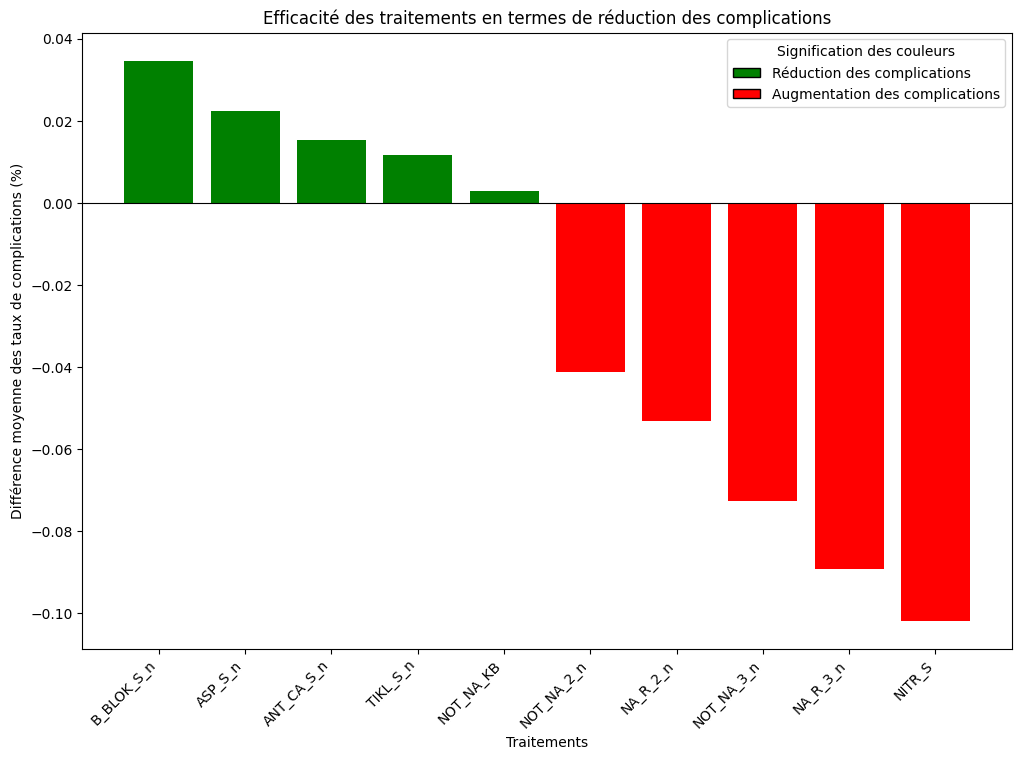

In [ ]:

# Préparer les données pour les traitements les plus efficaces et les moins efficaces
effective_treatments = effectiveness_sorted.head(5)
ineffective_treatments = effectiveness_sorted.tail(5)

# Créer un tableau combiné pour la visualisation
combined_treatments = pd.concat([effective_treatments, ineffective_treatments])
# Créer un graphique avec une légende mise à jour
plt.figure(figsize=(12, 8))
bars = plt.bar(combined_treatments.index, combined_treatments, color=['green' if x > 0 else 'red' for x in combined_treatments])
plt.title('Efficacité des traitements en termes de réduction des complications')
plt.xlabel('Traitements')
plt.ylabel('Différence moyenne des taux de complications (%)')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)  # Ajouter une ligne de référence à 0

# Ajouter une légende
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', edgecolor='black', label='Réduction des complications'),
                   Patch(facecolor='red', edgecolor='black', label='Augmentation des complications')]
plt.legend(handles=legend_elements, title="Signification des couleurs")

plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Sélectionner dix caractéristiques pour la prédiction
new_features = ['AGE', 'SEX', 'GB', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'S_AD_KBRIG', 'D_AD_KBRIG', 'L_BLOOD', 'K_BLOOD', 'DLIT_AG']
target = data['OTEK_LANC']  # Œdème pulmonaire

# Filtrer les lignes avec des valeurs manquantes dans les nouvelles caractéristiques
data_filtered = data[new_features].dropna()

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(data_filtered, target[data_filtered.index], test_size=0.3, random_state=42)

# Entraîner le modèle avec les nouvelles caractéristiques
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Calculer les importances des caractéristiques
feature_importances = model.feature_importances_

# Créer un DataFrame pour les importances des caractéristiques
importance_df = pd.DataFrame({'Feature': new_features, 'Importance': feature_importances})

# Trier les importances par ordre décroissant
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Afficher les importances des caractéristiques
importance_df


,Feature,Importance
8,L_BLOOD,0.193375
0,AGE,0.163433
9,K_BLOOD,0.146857
6,S_AD_KBRIG,0.114834
7,D_AD_KBRIG,0.077538
4,STENOK_AN,0.067893
10,DLIT_AG,0.058721
2,GB,0.056109
3,INF_ANAM,0.049343
5,FK_STENOK,0.040001


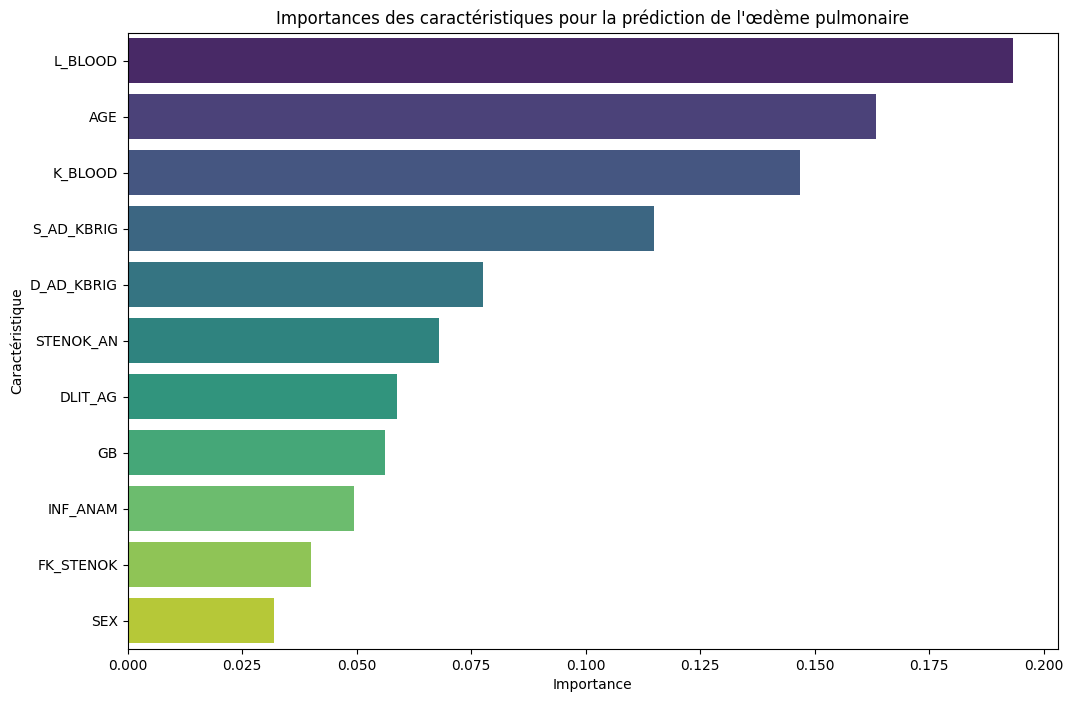

In [ ]:
# Visualiser les importances des caractéristiques
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Importances des caractéristiques pour la prédiction de l\'œdème pulmonaire')
plt.xlabel('Importance')
plt.ylabel('Caractéristique')
plt.show()


In [ ]:
# Réentraîner le modèle avec les dix caractéristiques sélectionnées
new_features = ['AGE', 'SEX', 'GB', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'S_AD_KBRIG', 'D_AD_KBRIG', 'L_BLOOD', 'K_BLOOD', 'DLIT_AG']
target = data['OTEK_LANC']  # Œdème pulmonaire

# Filtrer les lignes avec des valeurs manquantes dans les nouvelles caractéristiques
data_filtered = data[new_features].dropna()

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(data_filtered, target[data_filtered.index], test_size=0.3, random_state=42)

# Entraîner le modèle avec les nouvelles caractéristiques
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prédire sur l'ensemble de test
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Évaluer le modèle
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

accuracy, roc_auc


(0.9235294117647059, 0.648218085106383)

In [ ]:
# Liste des colonnes à exclure pour la prédiction au moment de l'admission
columns_to_exclude = [93, 94, 95, 100, 101, 102, 103, 104, 105]

# Sélection des colonnes pertinentes pour la prédiction au moment de l'admission
columns_to_include = [col for col in data.columns if col not in data.columns[columns_to_exclude]]

# Création d'un nouveau dataframe avec les colonnes sélectionnées
data_admission = data[columns_to_include]

# Affichage des premières lignes du nouveau dataframe pour vérifier la sélection
data_admission.head()


,ID,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,...,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS,Age_Group,Hypertension
0,1,77.0,1,2.0,1.0,1.0,2.0,0.0,3.0,0.0,...,0,0,0,0,0,0,0,0,60 and above,Yes
1,2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,Less than 60,No
2,3,52.0,1,0.0,0.0,0.0,2.0,0.0,2.0,0.0,...,0,0,0,0,0,0,0,0,Less than 60,Yes
3,4,68.0,0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,...,0,0,0,0,1,0,0,0,60 and above,Yes
4,5,60.0,1,0.0,0.0,0.0,2.0,0.0,3.0,0.0,...,0,0,0,0,0,0,0,0,60 and above,Yes


In [ ]:
# Statistiques descriptives des données
descriptive_stats = data_admission.describe()

# Identification des valeurs manquantes
missing_values = data_admission.isnull().sum()

# Affichage des statistiques descriptives et des valeurs manquantes
descriptive_stats, missing_values


(                ID          AGE          SEX     INF_ANAM    STENOK_AN  \
 count  1700.000000  1700.000000  1700.000000  1700.000000  1700.000000   
 mean    850.500000    61.871176     0.626471     0.554706     2.335294   
 std     490.892045    11.267646     0.483883     0.836172     2.440930   
 min       1.000000    26.000000     0.000000     0.000000     0.000000   
 25%     425.750000    54.000000     0.000000     0.000000     0.000000   
 50%     850.500000    63.000000     1.000000     0.000000     1.000000   
 75%    1275.250000    70.000000     1.000000     1.000000     5.000000   
 max    1700.000000    92.000000     1.000000     3.000000     6.000000   
 
          FK_STENOK     IBS_POST     IBS_NASL           GB   SIM_GIPERT  ...  \
 count  1700.000000  1700.000000  1700.000000  1700.000000  1700.000000  ...   
 mean      1.211176     1.164706     0.377647     1.394118     0.033529  ...   
 std       1.038173     0.802396     0.484941     1.089287     0.180067  ...   
 mi

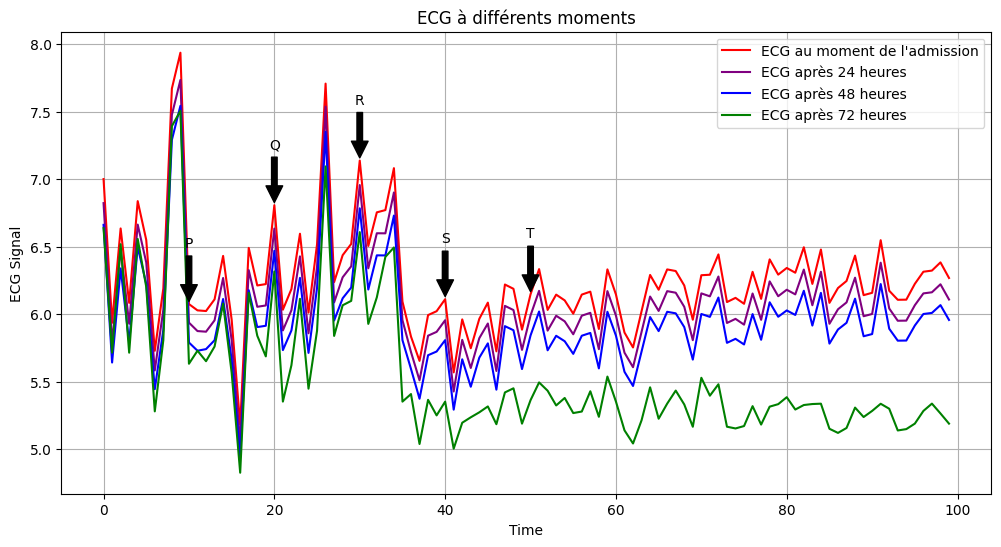

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données


# Définir les colonnes pour chaque scénario
columns_admission = [col for col in data.columns if col not in data.columns[[93, 94, 95, 100, 101, 102, 103, 104, 105]]]
columns_24h = [col for col in data.columns if col not in data.columns[[94, 95, 101, 102, 104, 105]]]
columns_48h = [col for col in data.columns if col not in data.columns[[95, 102, 105]]]
columns_72h = data.columns[2:112]

# Filtrer uniquement les colonnes numériques
def select_numeric_columns(data, columns):
    return data[columns].select_dtypes(include=['number'])

data_admission = select_numeric_columns(data, columns_admission)
data_24h = select_numeric_columns(data, columns_24h)
data_48h = select_numeric_columns(data, columns_48h)
data_72h = select_numeric_columns(data, columns_72h)

# Simuler les tracés ECG avec annotations pour les ondes P, Q, R, S, T
def simulate_ecg_with_waves(data, label, color, annotate=False):
    time = range(0, 100)
    ecg_signal = data.mean(axis=1).values[:100]  # Just a placeholder for a real ECG signal
    plt.plot(time, ecg_signal, label=label, color=color)

    # Annotating P, Q, R, S, T waves (optional, can be added to one of the plots if needed)
    if annotate:
        wave_points = {'P': 10, 'Q': 20, 'R': 30, 'S': 40, 'T': 50}
        for wave, t in wave_points.items():
            plt.annotate(wave, xy=(t, ecg_signal[t]), xytext=(t, ecg_signal[t] + 0.5),
                         arrowprops=dict(facecolor='black', shrink=0.05),
                         horizontalalignment='center', verticalalignment='top')

# Créer une figure pour tracer tous les scénarios
plt.figure(figsize=(12, 6))

# Tracer les scénarios avec des couleurs différentes
simulate_ecg_with_waves(data_admission, "ECG au moment de l'admission", color='red', annotate=True)
simulate_ecg_with_waves(data_24h, "ECG après 24 heures", color='purple')
simulate_ecg_with_waves(data_48h, "ECG après 48 heures", color='blue')
simulate_ecg_with_waves(data_72h, "ECG après 72 heures", color='green')

# Ajouter des titres et légendes
plt.title('ECG à différents moments')
plt.xlabel('Time')
plt.ylabel('ECG Signal')
plt.legend()
plt.grid(True)

# Afficher le graphique
plt.show()


In [ ]:
import pandas as pd

# Charger les données


# Convertir les colonnes de traitement en booléen
data['B_BLOK_S_n'] = data['B_BLOK_S_n'].astype(bool)
data['ASP_S_n'] = data['ASP_S_n'].astype(bool)
data['ANT_CA_S_n'] = data['ANT_CA_S_n'].astype(bool)
data['TIKL_S_n'] = data['TIKL_S_n'].astype(bool)
data['NOT_NA_KB'] = data['NOT_NA_KB'].astype(bool)

# Créer des combinaisons de traitements
data['B_BLOK_ASP'] = data['B_BLOK_S_n'] & data['ASP_S_n']
data['B_BLOK_ANT_CA'] = data['B_BLOK_S_n'] & data['ANT_CA_S_n']
data['ASP_ANT_CA'] = data['ASP_S_n'] & data['ANT_CA_S_n']

# Définir les colonnes de complications
complications_columns = ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC',
                         'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN', 'LET_IS']

# Calculer les taux de complications pour chaque combinaison de traitements
combination_columns = ['B_BLOK_ASP', 'B_BLOK_ANT_CA', 'ASP_ANT_CA']

complications_by_combination = {}
for combination in combination_columns:
    treated = data[data[combination] == True][complications_columns].mean()
    not_treated = data[data[combination] == False][complications_columns].mean()
    complications_by_combination[combination] = {
        'treated': treated,
        'not_treated': not_treated,
        'difference': treated - not_treated  # Positif signifie plus de complications chez les traités
    }

# Créer un DataFrame pour résumer les résultats
combination_df = pd.DataFrame(complications_by_combination).T

# Afficher les résultats
print("Complications par Combinaison de Traitements")
print(combination_df)

combination_df


Complications par Combinaison de Traitements
                                                         treated  \
B_BLOK_ASP     FIBR_PREDS    0.076471
PREDS_TAH     0.000000
...   
B_BLOK_ANT_CA  FIBR_PREDS    0.083333
PREDS_TAH     0.000000
...   
ASP_ANT_CA     FIBR_PREDS    0.108967
PREDS_TAH     0.012486
...   

                                                     not_treated  \
B_BLOK_ASP     FIBR_PREDS    0.102614
PREDS_TAH     0.013072
...   
B_BLOK_ANT_CA  FIBR_PREDS    0.101131
PREDS_TAH     0.012563
...   
ASP_ANT_CA     FIBR_PREDS    0.090354
PREDS_TAH     0.010989
...   

                                                      difference  
B_BLOK_ASP     FIBR_PREDS   -0.026144
PREDS_TAH    -0.013072
...  
B_BLOK_ANT_CA  FIBR_PREDS   -0.017797
PREDS_TAH    -0.012563
...  
ASP_ANT_CA     FIBR_PREDS    0.018613
PREDS_TAH     0.001497
...  


,treated,not_treated,difference
B_BLOK_ASP,FIBR_PREDS 0.076471 PREDS_TAH 0.000000 ...,FIBR_PREDS 0.102614 PREDS_TAH 0.013072 ...,FIBR_PREDS -0.026144 PREDS_TAH -0.013072 ...
B_BLOK_ANT_CA,FIBR_PREDS 0.083333 PREDS_TAH 0.000000 ...,FIBR_PREDS 0.101131 PREDS_TAH 0.012563 ...,FIBR_PREDS -0.017797 PREDS_TAH -0.012563 ...
ASP_ANT_CA,FIBR_PREDS 0.108967 PREDS_TAH 0.012486 ...,FIBR_PREDS 0.090354 PREDS_TAH 0.010989 ...,FIBR_PREDS 0.018613 PREDS_TAH 0.001497 ...


In [ ]:
from IPython.display import display

# Afficher les résultats
print("Complications par Combinaison de Traitements")
display(combination_df)


Complications par Combinaison de Traitements


,treated,not_treated,difference
B_BLOK_ASP,FIBR_PREDS 0.076471 PREDS_TAH 0.000000 ...,FIBR_PREDS 0.102614 PREDS_TAH 0.013072 ...,FIBR_PREDS -0.026144 PREDS_TAH -0.013072 ...
B_BLOK_ANT_CA,FIBR_PREDS 0.083333 PREDS_TAH 0.000000 ...,FIBR_PREDS 0.101131 PREDS_TAH 0.012563 ...,FIBR_PREDS -0.017797 PREDS_TAH -0.012563 ...
ASP_ANT_CA,FIBR_PREDS 0.108967 PREDS_TAH 0.012486 ...,FIBR_PREDS 0.090354 PREDS_TAH 0.010989 ...,FIBR_PREDS 0.018613 PREDS_TAH 0.001497 ...


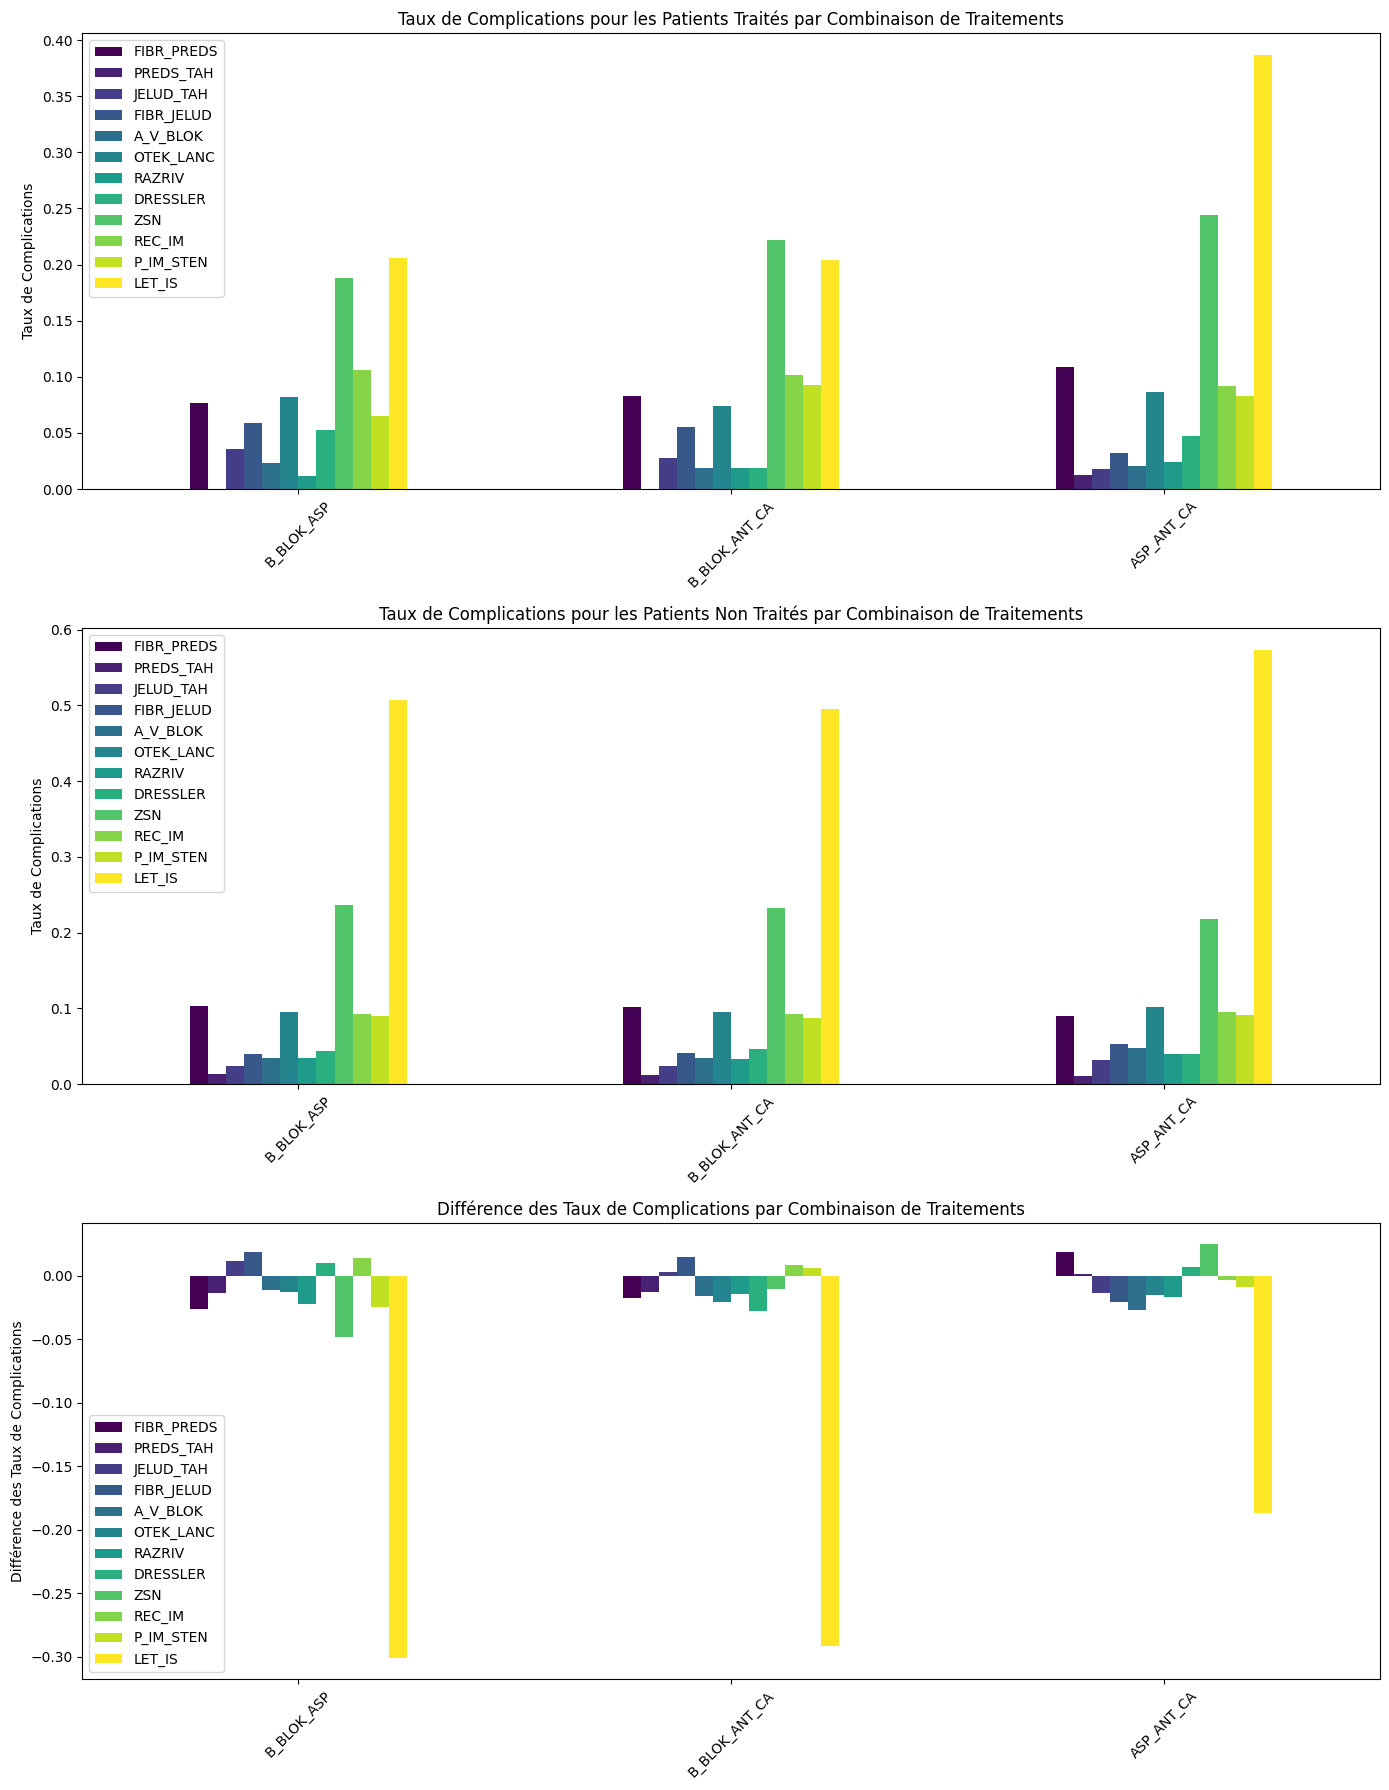

In [ ]:
import matplotlib.pyplot as plt

# Préparer les données pour la visualisation
combination_df_treated = combination_df['treated'].apply(pd.Series)
combination_df_not_treated = combination_df['not_treated'].apply(pd.Series)
combination_df_difference = combination_df['difference'].apply(pd.Series)

# Tracer les taux de complications pour chaque combinaison de traitements
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Visualisation pour les patients traités
combination_df_treated.plot(kind='bar', ax=axes[0], cmap='viridis')
axes[0].set_title('Taux de Complications pour les Patients Traités par Combinaison de Traitements')
axes[0].set_ylabel('Taux de Complications')
axes[0].set_xticklabels(combination_df_treated.index, rotation=45)

# Visualisation pour les patients non traités
combination_df_not_treated.plot(kind='bar', ax=axes[1], cmap='viridis')
axes[1].set_title('Taux de Complications pour les Patients Non Traités par Combinaison de Traitements')
axes[1].set_ylabel('Taux de Complications')
axes[1].set_xticklabels(combination_df_not_treated.index, rotation=45)

# Visualisation des différences
combination_df_difference.plot(kind='bar', ax=axes[2], cmap='viridis')
axes[2].set_title('Différence des Taux de Complications par Combinaison de Traitements')
axes[2].set_ylabel('Différence des Taux de Complications')
axes[2].set_xticklabels(combination_df_difference.index, rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Charger les données

# Sélectionner les colonnes démographiques et les complications
demographic_columns = ['AGE', 'SEX']
complications_columns = ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC']

# Créer des groupes d'âge
bins = [0, 50, 60, 70, 80, 100]
labels = ['<50', '50-59', '60-69', '70-79', '80+']
data['AGE_GROUP'] = pd.cut(data['AGE'], bins=bins, labels=labels, right=False)

# Calculer les taux de complications pour chaque groupe d'âge et sexe
complications_by_age_sex = data.groupby(['AGE_GROUP', 'SEX'], observed=True)[complications_columns].mean()

# Réinitialiser l'index pour faciliter la visualisation
complications_by_age_sex = complications_by_age_sex.reset_index()

# Afficher les résultats
print("Complications par Groupe d'Âge et Sexe")
print(complications_by_age_sex)

complications_by_age_sex


Complications par Groupe d'Âge et Sexe
  AGE_GROUP  SEX  FIBR_PREDS  PREDS_TAH  JELUD_TAH  FIBR_JELUD  A_V_BLOK  \
0       <50    0    0.050000   0.000000   0.000000    0.050000  0.050000   
1       <50    1    0.014851   0.004950   0.039604    0.044554  0.034653   
2     50-59    0    0.148148   0.024691   0.012346    0.061728  0.024691   
3     50-59    1    0.068376   0.011396   0.031339    0.048433  0.022792   
4     60-69    0    0.117188   0.007812   0.019531    0.035156  0.031250   
5     60-69    1    0.086207   0.014368   0.020115    0.051724  0.040230   
6     70-79    0    0.158879   0.018692   0.014019    0.014019  0.014019   
7     70-79    1    0.116788   0.007299   0.043796    0.029197  0.051095   
8       80+    0    0.187500   0.015625   0.015625    0.062500  0.093750   
9       80+    1    0.296296   0.000000   0.000000    0.037037  0.037037   

   OTEK_LANC  
0   0.150000  
1   0.039604  
2   0.061728  
3   0.079772  
4   0.101562  
5   0.086207  
6   0.135514  
7   

,AGE_GROUP,SEX,FIBR_PREDS,PREDS_TAH,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC
0,<50,0,0.050000,0.000000,0.000000,0.050000,0.050000,0.150000
1,<50,1,0.014851,0.004950,0.039604,0.044554,0.034653,0.039604
2,50-59,0,0.148148,0.024691,0.012346,0.061728,0.024691,0.061728
3,50-59,1,0.068376,0.011396,0.031339,0.048433,0.022792,0.079772
4,60-69,0,0.117188,0.007812,0.019531,0.035156,0.031250,0.101562
5,60-69,1,0.086207,0.014368,0.020115,0.051724,0.040230,0.086207
6,70-79,0,0.158879,0.018692,0.014019,0.014019,0.014019,0.135514
7,70-79,1,0.116788,0.007299,0.043796,0.029197,0.051095,0.109489
8,80+,0,0.187500,0.015625,0.015625,0.062500,0.093750,0.187500
9,80+,1,0.296296,0.000000,0.000000,0.037037,0.037037,0.111111


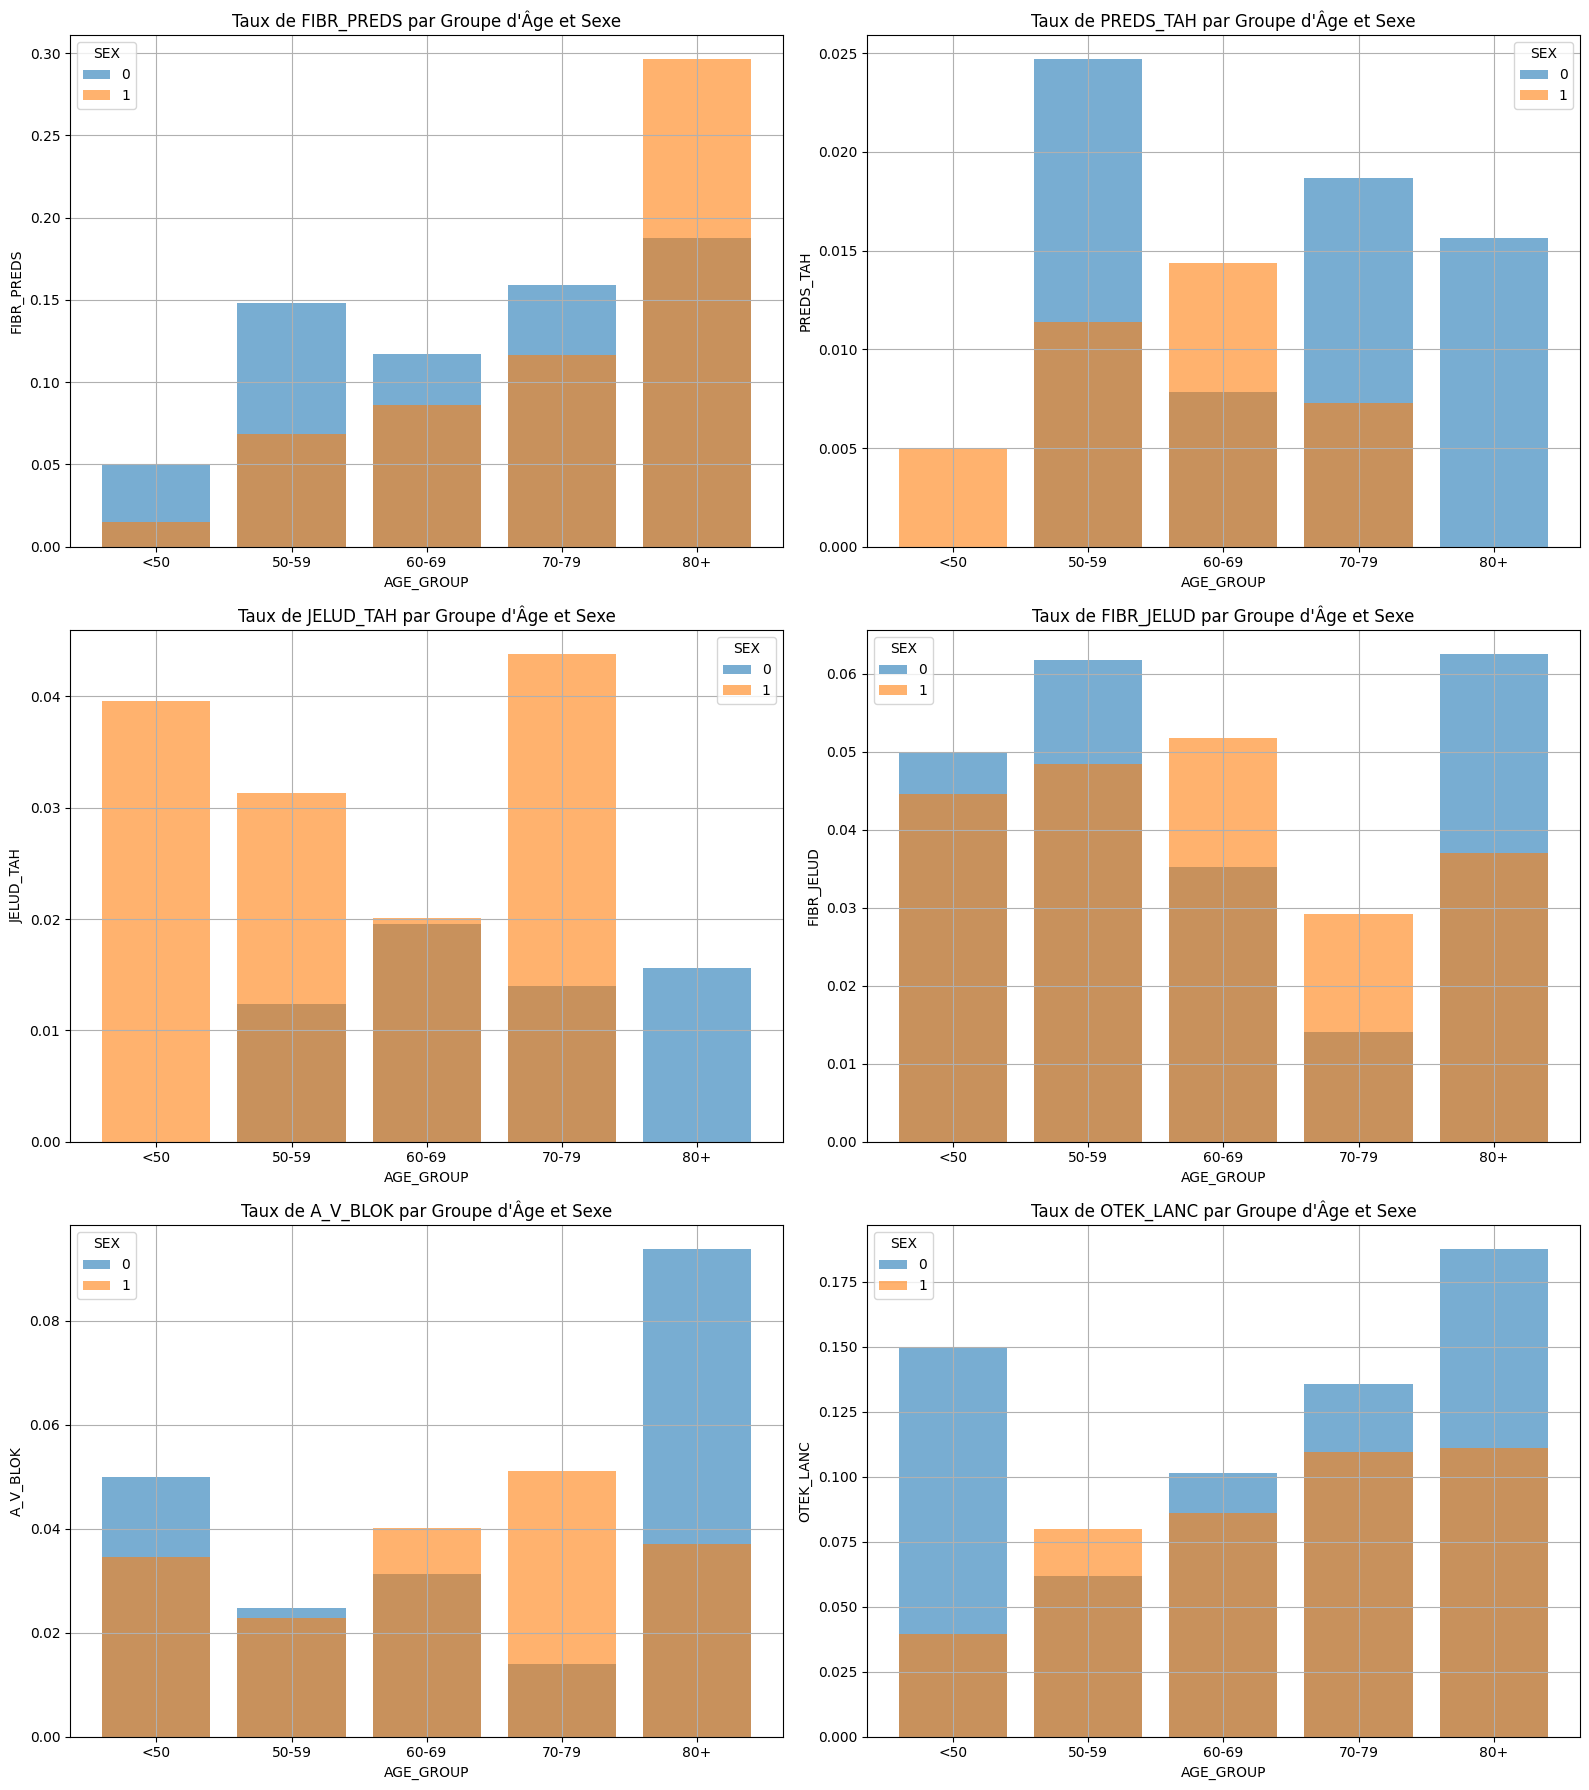

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données


# Sélectionner les colonnes démographiques et les complications
demographic_columns = ['AGE', 'SEX']
complications_columns = ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC']

# Créer des groupes d'âge
bins = [0, 50, 60, 70, 80, 100]
labels = ['<50', '50-59', '60-69', '70-79', '80+']
data['AGE_GROUP'] = pd.cut(data['AGE'], bins=bins, labels=labels, right=False)

# Calculer les taux de complications pour chaque groupe d'âge et sexe
complications_by_age_sex = data.groupby(['AGE_GROUP', 'SEX'], observed=True)[complications_columns].mean().reset_index()

# Fonction pour tracer un barplot sans regroupement interne dans Seaborn
def custom_barplot(data, x, y, hue, ax):
    unique_hue = data[hue].unique()
    palette = sns.color_palette(n_colors=len(unique_hue))

    for i, hue_value in enumerate(unique_hue):
        subset = data[data[hue] == hue_value]
        ax.bar(subset[x], subset[y], color=palette[i], label=hue_value, alpha=0.6)

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(title=hue)
    ax.grid(True)

# Créer des graphiques pour les taux de complications par groupe d'âge et sexe
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for i, complication in enumerate(complications_columns):
    custom_barplot(complications_by_age_sex, 'AGE_GROUP', complication, 'SEX', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Taux de {complication} par Groupe d\'Âge et Sexe')

plt.tight_layout()
plt.show()


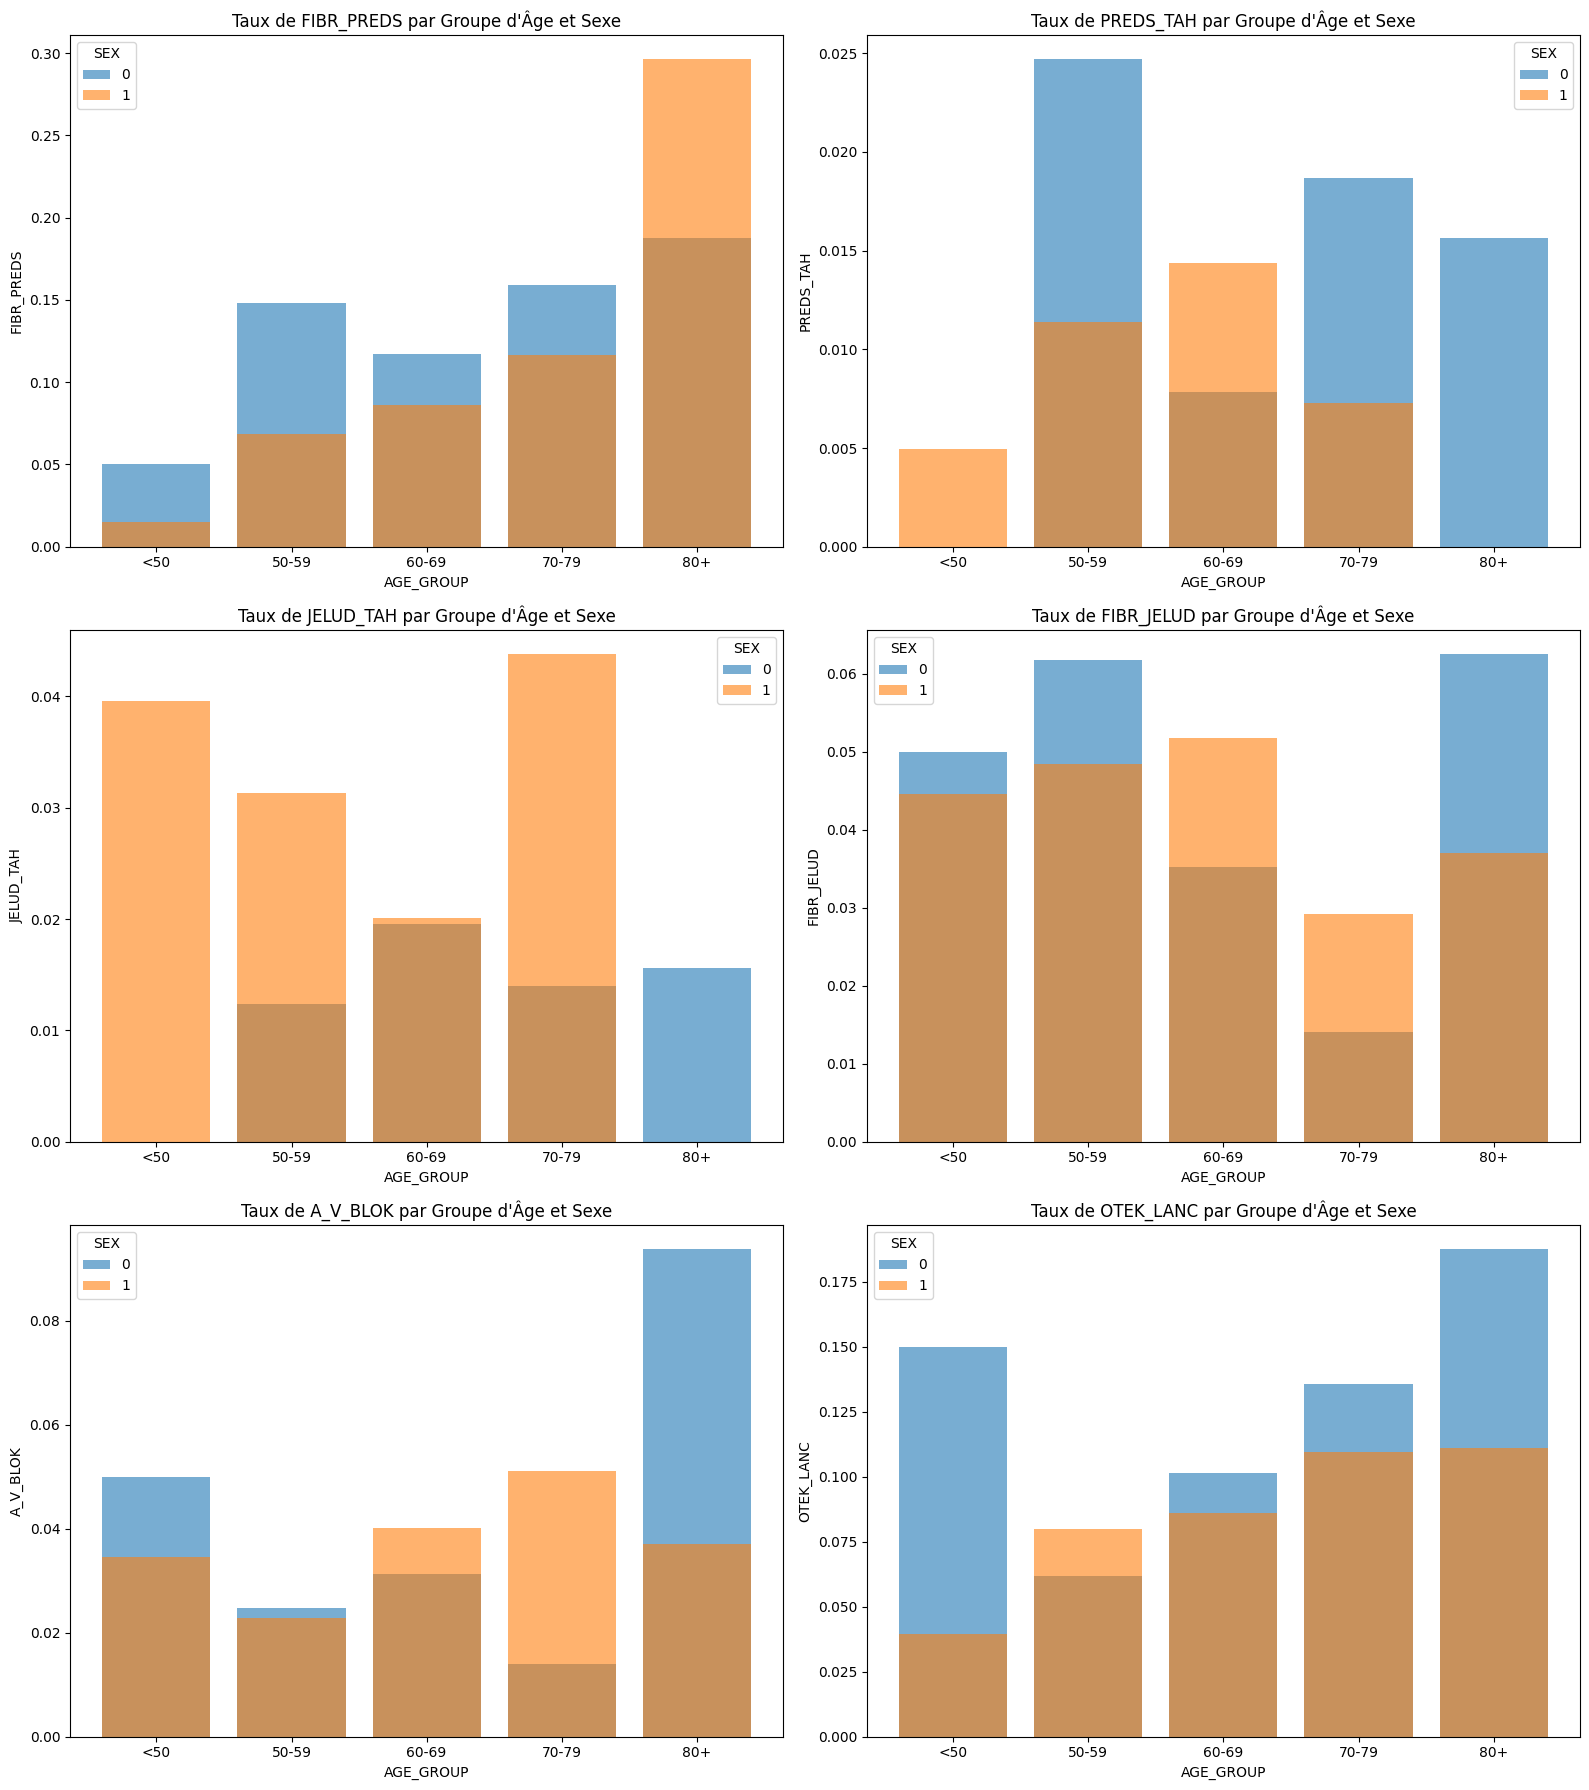

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
# file_path = '/mnt/data/Myocardial_infarction.csv'
# data = pd.read_csv(file_path)

# Sélectionner les colonnes démographiques et les complications
demographic_columns = ['AGE', 'SEX']
complications_columns = ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC']

# Créer des groupes d'âge
bins = [0, 50, 60, 70, 80, 100]
labels = ['<50', '50-59', '60-69', '70-79', '80+']
data['AGE_GROUP'] = pd.cut(data['AGE'], bins=bins, labels=labels, right=False)

# Calculer les taux de complications pour chaque groupe d'âge et sexe
complications_by_age_sex = data.groupby(['AGE_GROUP', 'SEX'], observed=True)[complications_columns].mean().reset_index()

# Fonction pour tracer un barplot sans regroupement interne dans Seaborn
def custom_barplot(data, x, y, hue, ax):
    unique_hue = data[hue].unique()
    palette = sns.color_palette(n_colors=len(unique_hue))

    for i, hue_value in enumerate(unique_hue):
        subset = data[data[hue] == hue_value]
        ax.bar(subset[x], subset[y], color=palette[i], label=hue_value, alpha=0.6)

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(title=hue)
    ax.grid(False)

# Créer des graphiques pour les taux de complications par groupe d'âge et sexe
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for i, complication in enumerate(complications_columns):
    custom_barplot(complications_by_age_sex, 'AGE_GROUP', complication, 'SEX', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Taux de {complication} par Groupe d\'Âge et Sexe')

plt.tight_layout()
plt.show()


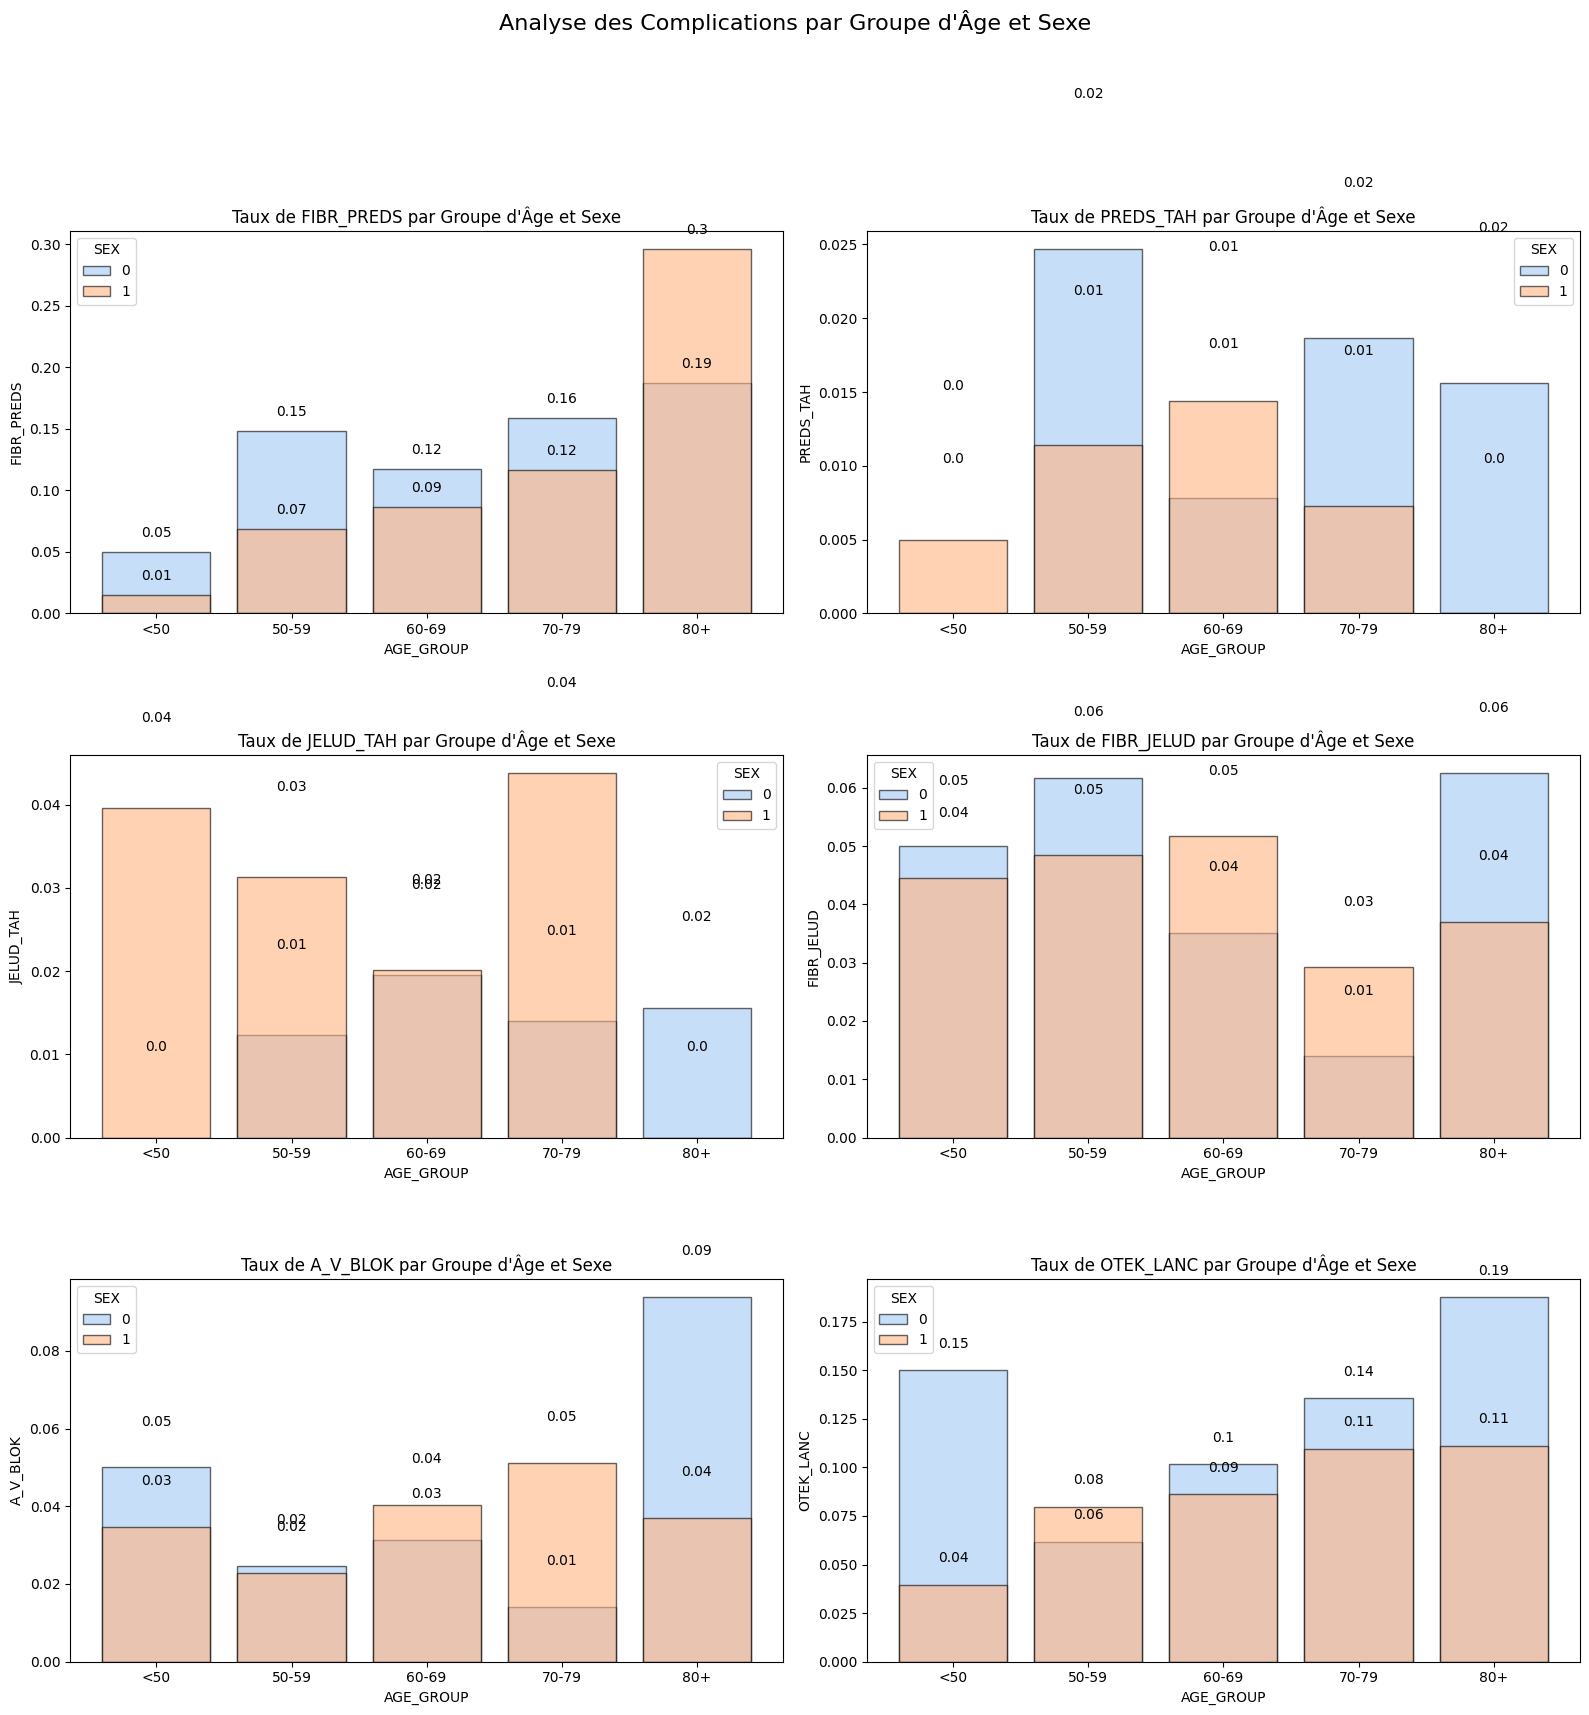

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données


# Sélectionner les colonnes démographiques et les complications
demographic_columns = ['AGE', 'SEX']
complications_columns = ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC']

# Créer des groupes d'âge
bins = [0, 50, 60, 70, 80, 100]
labels = ['<50', '50-59', '60-69', '70-79', '80+']
data['AGE_GROUP'] = pd.cut(data['AGE'], bins=bins, labels=labels, right=False)

# Calculer les taux de complications pour chaque groupe d'âge et sexe
complications_by_age_sex = data.groupby(['AGE_GROUP', 'SEX'], observed=True)[complications_columns].mean().reset_index()

# Fonction pour tracer un barplot sans regroupement interne dans Seaborn
def custom_barplot(data, x, y, hue, ax):
    unique_hue = data[hue].unique()
    palette = sns.color_palette('pastel', n_colors=len(unique_hue))

    for i, hue_value in enumerate(unique_hue):
        subset = data[data[hue] == hue_value]
        bars = ax.bar(subset[x], subset[y], color=palette[i], label=hue_value, alpha=0.6, edgecolor='black')

        # Ajouter des annotations sur chaque barre
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(title=hue)
    ax.grid(False)

# Créer des graphiques pour les taux de complications par groupe d'âge et sexe
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for i, complication in enumerate(complications_columns):
    custom_barplot(complications_by_age_sex, 'AGE_GROUP', complication, 'SEX', ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Taux de {complication} par Groupe d\'Âge et Sexe')

# Améliorer la mise en page et ajouter un titre général
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("Analyse des Complications par Groupe d'Âge et Sexe", fontsize=16)

plt.show()


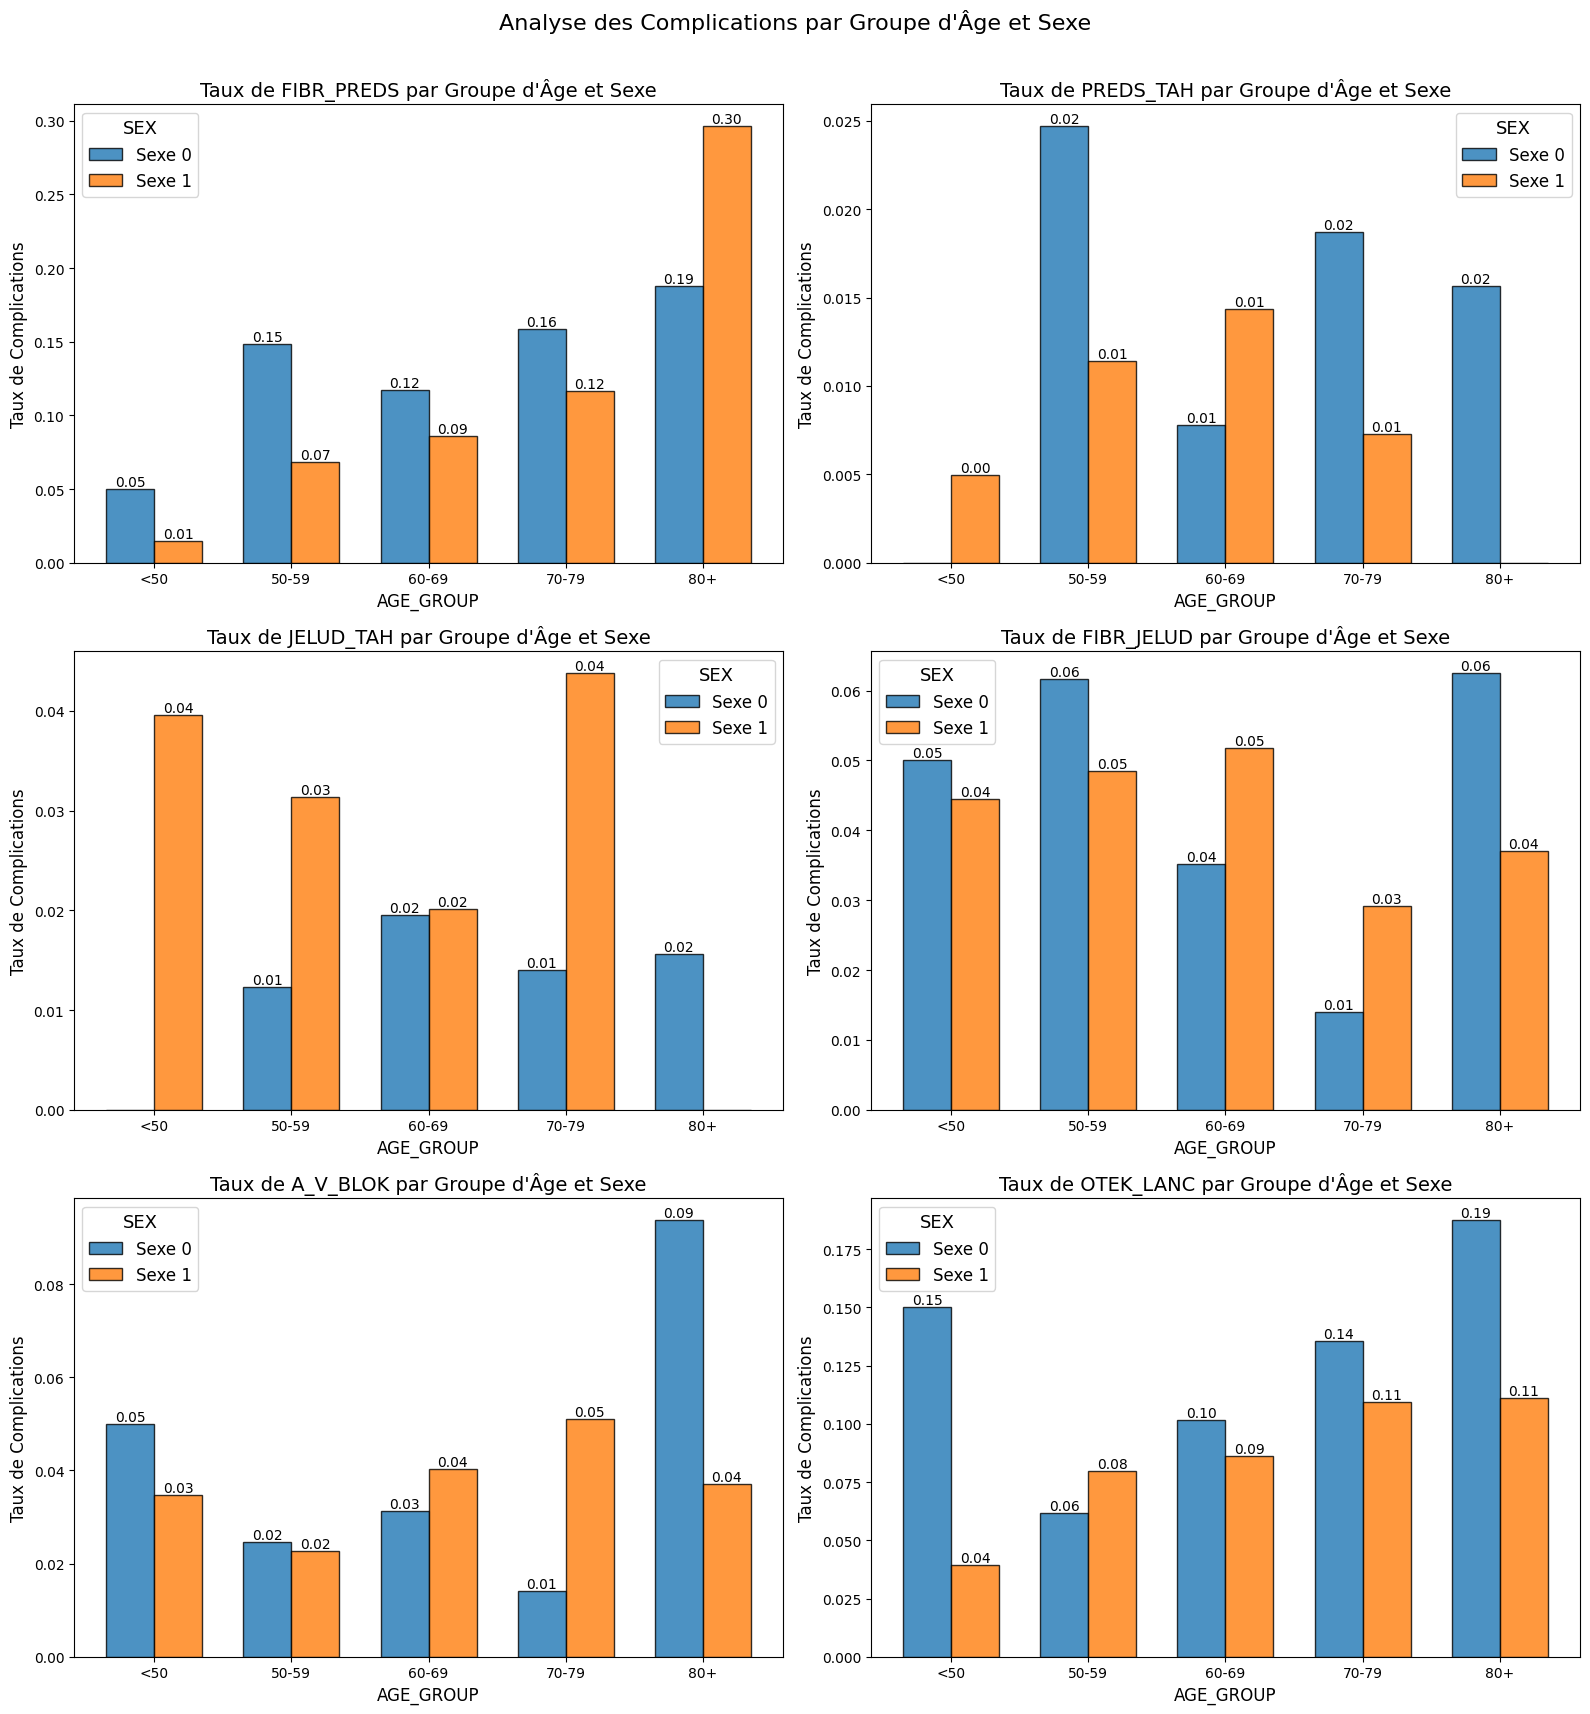

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
# file_path = '/mnt/data/Myocardial_infarction.csv'
# data = pd.read_csv(file_path)

# Sélectionner les colonnes démographiques et les complications
demographic_columns = ['AGE', 'SEX']
complications_columns = ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC']

# Créer des groupes d'âge
bins = [0, 50, 60, 70, 80, 100]
labels = ['<50', '50-59', '60-69', '70-79', '80+']
data['AGE_GROUP'] = pd.cut(data['AGE'], bins=bins, labels=labels, right=False)

# Calculer les taux de complications pour chaque groupe d'âge et sexe
complications_by_age_sex = data.groupby(['AGE_GROUP', 'SEX'], observed=True)[complications_columns].mean().reset_index()

# Définir une palette de couleurs personnalisée
custom_palette = ['#1f77b4', '#ff7f0e']  # Bleu et Orange vifs

# Fonction pour tracer des barplots empilés côte à côte pour chaque sexe
def custom_barplot(data, x, y, hue, ax):
    unique_x = data[x].unique()
    unique_hue = data[hue].unique()
    bar_width = 0.35  # Largeur des barres
    bar_positions = {label: idx for idx, label in enumerate(unique_x)}

    for i, hue_value in enumerate(unique_hue):
        subset = data[data[hue] == hue_value]
        positions = [bar_positions[label] + (i * bar_width - bar_width / 2) for label in subset[x]]
        bars = ax.bar(positions, subset[y], bar_width, label=f'Sexe {hue_value}', color=custom_palette[i], alpha=0.8, edgecolor='black')

        # Ajouter des annotations sur chaque barre
        for bar in bars:
            yval = bar.get_height()
            if yval > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

    ax.set_xticks([bar_positions[label] for label in unique_x])
    ax.set_xticklabels(unique_x)
    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel('Taux de Complications', fontsize=12)
    ax.legend(title=hue, fontsize=12, title_fontsize='13')
    ax.grid(False)

# Créer des graphiques pour les taux de complications par groupe d'âge et sexe
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for i, complication in enumerate(complications_columns):
    custom_barplot(complications_by_age_sex, 'AGE_GROUP', complication, 'SEX', ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title(f'Taux de {complication} par Groupe d\'Âge et Sexe', fontsize=14)

# Améliorer la mise en page et ajouter un titre général
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("Analyse des Complications par Groupe d'Âge et Sexe", fontsize=16)

plt.show()


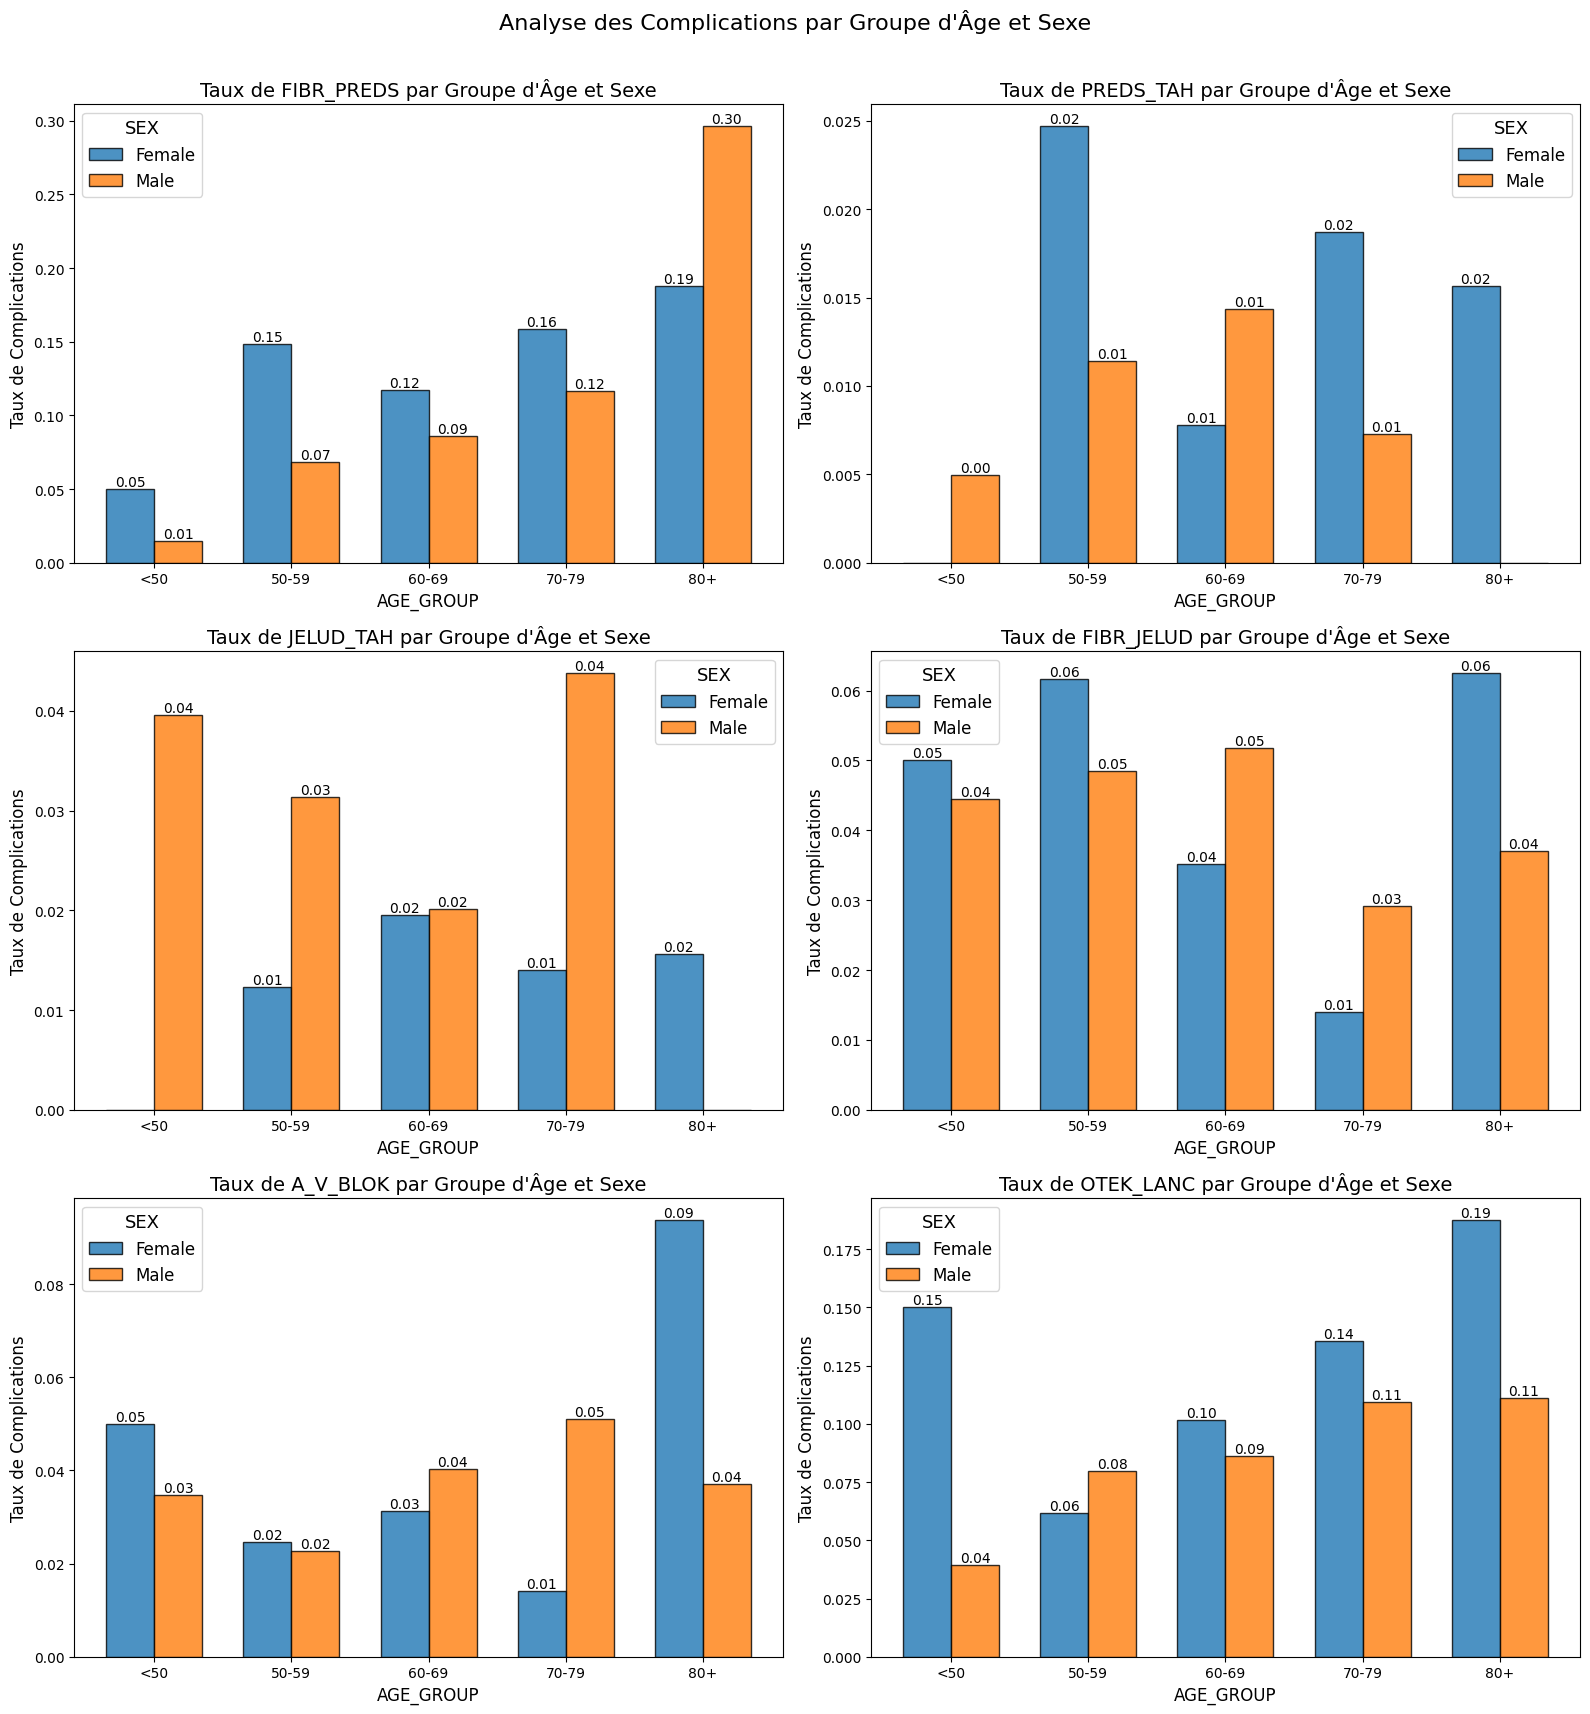

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
# file_path = '/mnt/data/Myocardial_infarction.csv'
# data = pd.read_csv(file_path)

# Sélectionner les colonnes démographiques et les complications
demographic_columns = ['AGE', 'SEX']
complications_columns = ['FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC']

# Créer des groupes d'âge
bins = [0, 50, 60, 70, 80, 100]
labels = ['<50', '50-59', '60-69', '70-79', '80+']
data['AGE_GROUP'] = pd.cut(data['AGE'], bins=bins, labels=labels, right=False)

# Calculer les taux de complications pour chaque groupe d'âge et sexe
complications_by_age_sex = data.groupby(['AGE_GROUP', 'SEX'], observed=True)[complications_columns].mean().reset_index()

# Définir une palette de couleurs personnalisée
custom_palette = ['#1f77b4', '#ff7f0e']  # Bleu et Orange vifs

# Map pour changer 0 en "Female" et 1 en "Male"
sex_labels = {0: 'Female', 1: 'Male'}
complications_by_age_sex['SEX'] = complications_by_age_sex['SEX'].map(sex_labels)

# Fonction pour tracer des barplots empilés côte à côte pour chaque sexe
def custom_barplot(data, x, y, hue, ax):
    unique_x = data[x].unique()
    unique_hue = data[hue].unique()
    bar_width = 0.35  # Largeur des barres
    bar_positions = {label: idx for idx, label in enumerate(unique_x)}

    for i, hue_value in enumerate(unique_hue):
        subset = data[data[hue] == hue_value]
        positions = [bar_positions[label] + (i * bar_width - bar_width / 2) for label in subset[x]]
        bars = ax.bar(positions, subset[y], bar_width, label=hue_value, color=custom_palette[i], alpha=0.8, edgecolor='black')

        # Ajouter des annotations sur chaque barre
        for bar in bars:
            yval = bar.get_height()
            if yval > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

    ax.set_xticks([bar_positions[label] for label in unique_x])
    ax.set_xticklabels(unique_x)
    ax.set_xlabel(x, fontsize=12)
    ax.set_ylabel('Taux de Complications', fontsize=12)
    ax.legend(title=hue, fontsize=12, title_fontsize='13')
    ax.grid(False)

# Créer des graphiques pour les taux de complications par groupe d'âge et sexe
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for i, complication in enumerate(complications_columns):
    custom_barplot(complications_by_age_sex, 'AGE_GROUP', complication, 'SEX', ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title(f'Taux de {complication} par Groupe d\'Âge et Sexe', fontsize=14)

# Améliorer la mise en page et ajouter un titre général
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("Analyse des Complications par Groupe d'Âge et Sexe", fontsize=16)

plt.show()


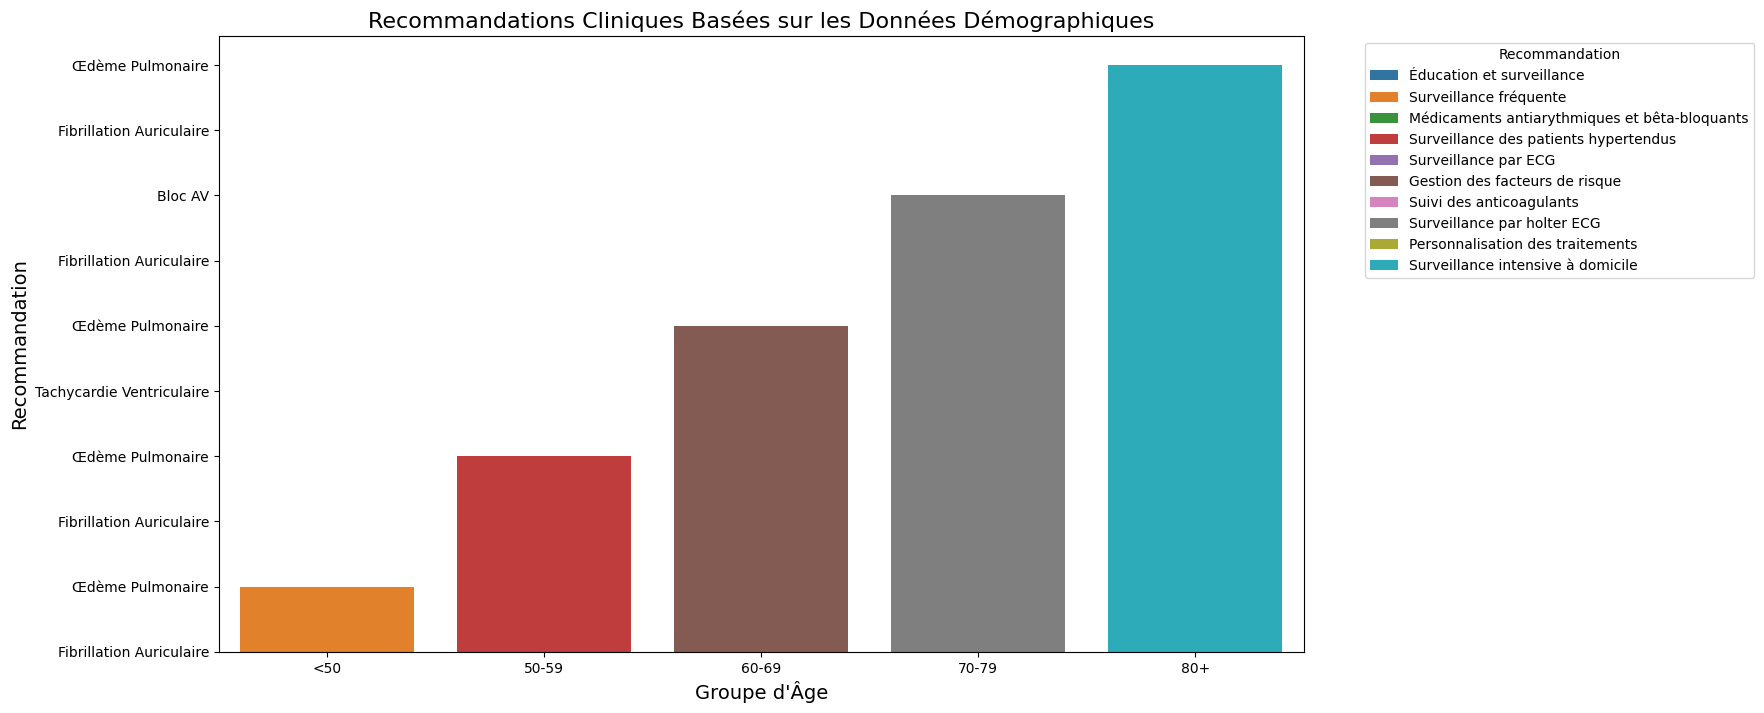

In [ ]:
# Préparer les données pour le diagramme en bande
recommendations_bars = {
    'Group': ['<50', '<50', '50-59', '50-59', '60-69', '60-69', '70-79', '70-79', '80+', '80+'],
    'Complication': ['Fibrillation Auriculaire', 'Œdème Pulmonaire', 'Fibrillation Auriculaire', 'Œdème Pulmonaire',
                     'Tachycardie Ventriculaire', 'Œdème Pulmonaire', 'Fibrillation Auriculaire', 'Bloc AV',
                     'Fibrillation Auriculaire', 'Œdème Pulmonaire'],
    'Recommendation': ['Éducation et surveillance', 'Surveillance fréquente',
                       'Médicaments antiarythmiques et bêta-bloquants', 'Surveillance des patients hypertendus',
                       'Surveillance par ECG', 'Gestion des facteurs de risque',
                       'Suivi des anticoagulants', 'Surveillance par holter ECG',
                       'Personnalisation des traitements', 'Surveillance intensive à domicile']
}

recommendations_df_bars = pd.DataFrame(recommendations_bars)

# Créer une colonne numérique pour l'axe des y
recommendations_df_bars['y_pos'] = range(len(recommendations_df_bars))

# Créer un diagramme en bande
plt.figure(figsize=(14, 8))
sns.barplot(x='Group', y='y_pos', hue='Recommendation', data=recommendations_df_bars, dodge=False)
plt.title('Recommandations Cliniques Basées sur les Données Démographiques', fontsize=16)
plt.xlabel('Groupe d\'Âge', fontsize=14)
plt.ylabel('Recommandation', fontsize=14)
plt.yticks(ticks=recommendations_df_bars['y_pos'], labels=recommendations_df_bars['Complication'])
plt.legend(title='Recommandation', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


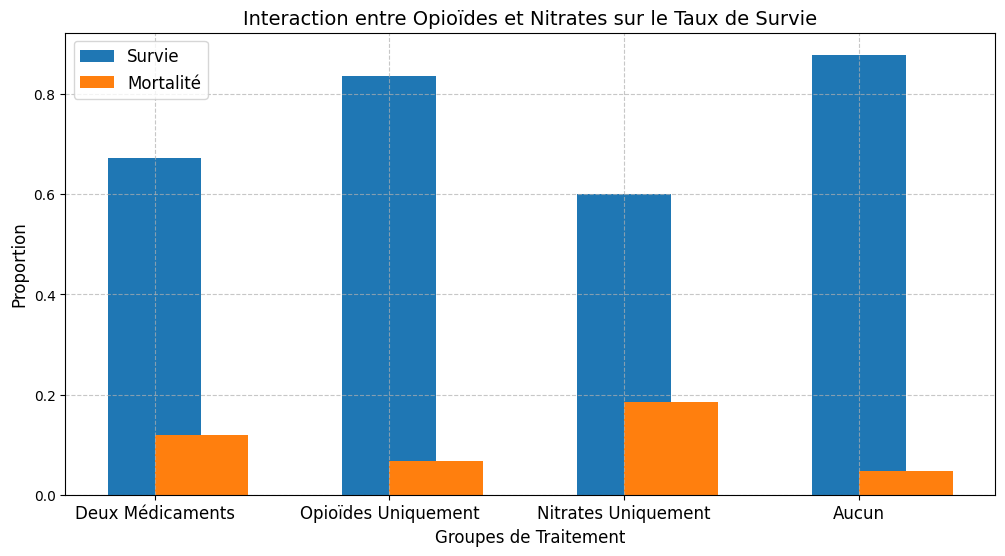

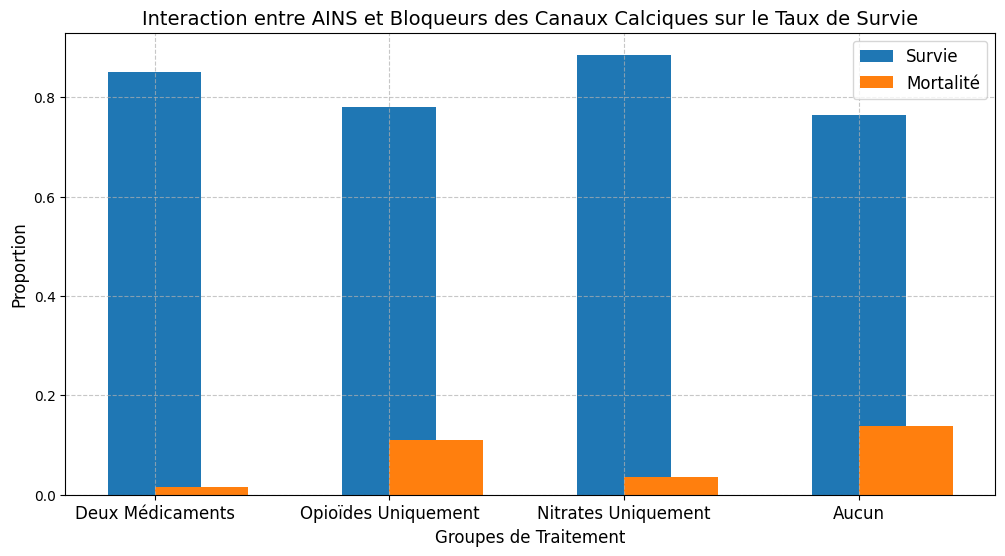

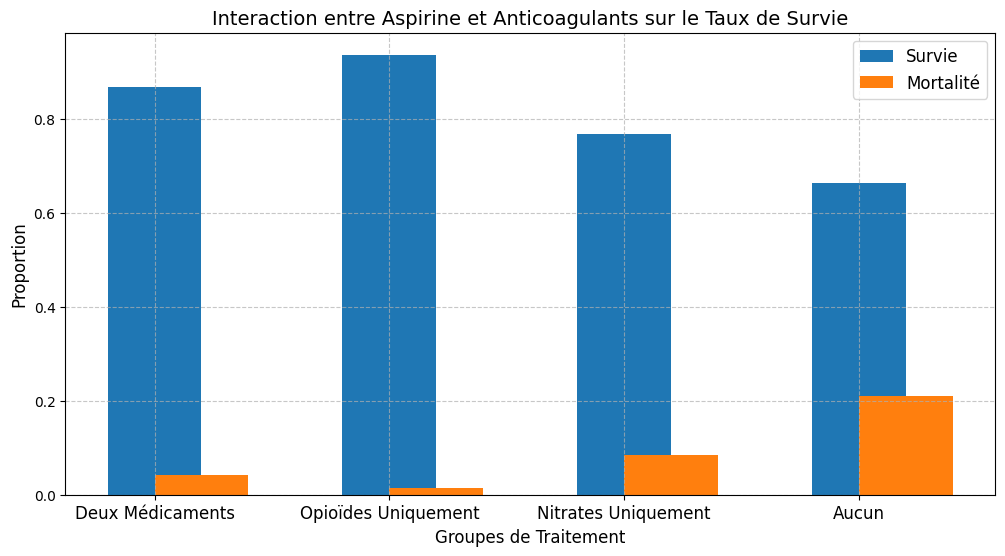

In [ ]:


# Fonction pour analyser la distribution des résultats cliniques pour les interactions significatives
def analyze_significant_interactions(data, treatment1, treatment2, outcome='LET_IS'):
    treated1 = data[treatment1] == 1
    treated2 = data[treatment2] == 1

    treated_both = data[treated1 & treated2]
    treated_t1_only = data[treated1 & ~treated2]
    treated_t2_only = data[~treated1 & treated2]
    not_treated = data[~treated1 & ~treated2]

    outcome_counts = {
        'both': treated_both[outcome].value_counts(normalize=True).sort_index(),
        't1_only': treated_t1_only[outcome].value_counts(normalize=True).sort_index(),
        't2_only': treated_t2_only[outcome].value_counts(normalize=True).sort_index(),
        'none': not_treated[outcome].value_counts(normalize=True).sort_index()
    }

    return outcome_counts

# Visualiser les résultats
def plot_interaction_results(outcome_counts, title):
    groups = ['both', 't1_only', 't2_only', 'none']
    survival_rates = [outcome_counts[group].get(0, 0) for group in groups]
    mortality_rates = [outcome_counts[group].get(1, 0) for group in groups]

    x = range(len(groups))

    plt.figure(figsize=(12, 6))
    plt.bar(x, survival_rates, width=0.4, label='Survie', color='#1f77b4', align='center')  # Couleur bleu vif
    plt.bar(x, mortality_rates, width=0.4, label='Mortalité', color='#ff7f0e', align='edge')  # Couleur orange vif
    plt.xlabel('Groupes de Traitement', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.title(title, fontsize=14)
    plt.xticks(x, ['Deux Médicaments', 'Opioïdes Uniquement', 'Nitrates Uniquement', 'Aucun'], fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Analyser et visualiser l'interaction entre NA_R_1_n et NITR_S
interaction_outcome_opioids_nitrates = analyze_significant_interactions(data, 'NA_R_1_n', 'NITR_S')
plot_interaction_results(interaction_outcome_opioids_nitrates, 'Interaction entre Opioïdes et Nitrates sur le Taux de Survie')

# Analyser et visualiser l'interaction entre NOT_NA_1_n et ANT_CA_S_n
interaction_outcome_ains_calcium_blockers = analyze_significant_interactions(data, 'NOT_NA_1_n', 'ANT_CA_S_n')
plot_interaction_results(interaction_outcome_ains_calcium_blockers, 'Interaction entre AINS et Bloqueurs des Canaux Calciques sur le Taux de Survie')

# Analyser et visualiser l'interaction entre ASP_S_n et GEPAR_S_n
interaction_outcome_aspirin_anticoagulants = analyze_significant_interactions(data, 'ASP_S_n', 'GEPAR_S_n')
plot_interaction_results(interaction_outcome_aspirin_anticoagulants, 'Interaction entre Aspirine et Anticoagulants sur le Taux de Survie')
